In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns # for plotting stuff
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brazil-weather-information-by-inmet/stations.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_2013/weather_2013.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_2017/weather_2017.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_2018/weather_2018.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_2012/weather_2012.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_2001/weather_2001.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_2021/weather_2021.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2005/weather_sum_2005.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2015/weather_sum_2015.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2003/weather_sum_2003.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2016/weather_sum_2016.csv
/kaggle/input/brazil-weather-information-by-inmet/weather_2003/weather_2003.csv
/kaggle/input/brazil-weat

Definições de constantes

In [2]:
NORTE_ESTADOS = ['AMAZONAS', 'AMAPA', 'RORAIMA', 'RONDONIA', 'TOCANTINS', 'ACRE', 'PARA']
NORDESTE_ESTADOS = ['MARANHAO', 'PIAUI', 'CEARA', 'RIO GRANDE DO NORTE', 'PARAIBA', 'PERNAMBUCO', 'ALAGOAS', 'SERGIPE', 'BAHIA']
CENTRO_OESTE_ESTADOS = ['MATO GROSSO', 'MATO GROSSO DO SUL', 'GOIAS', 'DISTRITO FEDERAL']
SUDESTE_ESTADOS = ['MINAS GERAIS', 'ESPIRITO SANTO', 'RIO DE JANEIRO', 'SAO PAULO']
SUL_ESTADOS = ['PARANA', 'SANTA CATARINA', 'RIO GRANDE DO SUL']

NORTE_ABREVIACOES = ['AM', 'AP', 'RR', 'RO', 'TO', 'AC', 'PA']
NORDESTE_ABREVIACOES = ['MA', 'PI', 'CE', 'RN', 'PB', 'PE', 'AL', 'SE', 'BA']
CENTRO_OESTE_ABREVIACOES = ['MT', 'MS', 'GO', 'DF']
SUDESTE_ABREVIACOES = ['MG', 'ES', 'RJ', 'SP']
SUL_ABREVIACOES = ['PR', 'SC', 'RS']

Definições dos dataframes (demora uns 3 min para carregar tudo)

In [3]:
%%time
df_stations = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/stations.csv')

df_2000 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2000/weather_2000.csv')
df_2000_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2000/weather_sum_2000.csv')
print('2000 DONE')
df_2001 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2001/weather_2001.csv')
df_2001_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2001/weather_sum_2001.csv')
print('2001 DONE')
df_2002 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2002/weather_2002.csv')
df_2002_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2002/weather_sum_2002.csv')
print('2002 DONE')
df_2003 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2003/weather_2003.csv')
df_2003_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2003/weather_sum_2003.csv')
print('2003 DONE')
df_2004 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2004/weather_2004.csv')
df_2004_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2004/weather_sum_2004.csv')
print('2004 DONE')
df_2005 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2005/weather_2005.csv')
df_2005_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2005/weather_sum_2005.csv')
print('2005 DONE')
df_2006 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2006/weather_2006.csv')
df_2006_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2006/weather_sum_2006.csv')
print('2006 DONE')
df_2007 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2007/weather_2007.csv')
df_2007_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2007/weather_sum_2007.csv')
print('2007 DONE')
df_2008 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2008/weather_2008.csv')
df_2008_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2008/weather_sum_2008.csv')
print('2008 DONE')
df_2009 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2009/weather_2009.csv')
df_2009_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2009/weather_sum_2009.csv')
print('2009 DONE')
df_2010 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2010/weather_2010.csv')
df_2010_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2010/weather_sum_2010.csv')
print('2010 DONE')
df_2011 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2011/weather_2011.csv')
df_2011_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2011/weather_sum_2011.csv')
print('2011 DONE')
df_2012 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2012/weather_2012.csv')
df_2012_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2012/weather_sum_2012.csv')
print('2012 DONE')
df_2013 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2013/weather_2013.csv')
df_2013_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2013/weather_sum_2013.csv')
print('2013 DONE')
df_2014 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2014/weather_2014.csv')
df_2014_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2014/weather_sum_2014.csv')
print('2014 DONE')
df_2015 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2015/weather_2015.csv')
df_2015_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2015/weather_sum_2015.csv')
print('2015 DONE')
df_2016 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2016/weather_2016.csv')
df_2016_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2016/weather_sum_2016.csv')
print('2016 DONE')
df_2017 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2017/weather_2017.csv')
df_2017_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2017/weather_sum_2017.csv')
print('2017 DONE')
df_2018 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2018/weather_2018.csv')
df_2018_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2018/weather_sum_2018.csv')
print('2018 DONE')
df_2019 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2019/weather_2019.csv')
df_2019_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2019/weather_sum_2019.csv')
print('2019 DONE')
df_2020 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2020/weather_2020.csv')
df_2020_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2020/weather_sum_2020.csv')
print('2020 DONE')
df_2021 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2021/weather_2021.csv')
df_2021_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2021/weather_sum_2021.csv')
print('2021 DONE')
df_2022 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2022/weather_2022.csv')
df_2022_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2022/weather_sum_2022.csv')
print('2022 DONE')
df_2023 = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_2023/weather_2023.csv')
df_2023_sum = pd.read_csv('/kaggle/input/brazil-weather-information-by-inmet/weather_sum_2023/weather_sum_2023.csv')
print('2023 DONE')

2000 DONE
2001 DONE
2002 DONE
2003 DONE
2004 DONE
2005 DONE
2006 DONE
2007 DONE
2008 DONE
2009 DONE
2010 DONE
2011 DONE
2012 DONE
2013 DONE
2014 DONE
2015 DONE
2016 DONE
2017 DONE
2018 DONE
2019 DONE
2020 DONE
2021 DONE
2022 DONE
2023 DONE
CPU times: user 1min 50s, sys: 14.3 s, total: 2min 4s
Wall time: 2min 47s


In [4]:
# listas com todos dataframes
dfs_list = [df_2000, df_2001, df_2002, df_2003, df_2004, df_2005, df_2006, df_2007, df_2008, df_2009, df_2010, df_2011, df_2012, df_2013, df_2014, df_2015, df_2016, df_2017, df_2018, df_2019, df_2020, df_2021, df_2022, df_2023]
dfs_sum_list = [df_2000_sum, df_2001_sum, df_2002_sum, df_2003_sum, df_2004_sum, df_2005_sum, df_2006_sum, df_2007_sum, df_2008_sum, df_2009_sum, df_2010_sum, df_2011_sum, df_2012_sum, df_2013_sum, df_2014_sum, df_2015_sum, df_2016_sum, df_2017_sum, df_2018_sum, df_2019_sum, df_2020_sum, df_2021_sum, df_2022_sum, df_2023_sum]

In [5]:
%%time
# juntando todos os dataframes em 1 (1 para o sum e 1 para o outro)
# all_df = pd.concat(dfs_list) # ISSO TA ESTOURANDO A MEMORIA KK 😭
all_df_sum = pd.concat(dfs_sum_list)

CPU times: user 50.3 ms, sys: 44.1 ms, total: 94.5 ms
Wall time: 95.3 ms


In [6]:
# Estacoes por regioes
se_stations = df_stations[df_stations['region'] == 'SE']['id_station'].tolist()
s_stations = df_stations[df_stations['region'] == 'S']['id_station'].tolist()
co_stations = df_stations[df_stations['region'] == 'CO']['id_station'].tolist()
n_stations = df_stations[df_stations['region'] == 'N']['id_station'].tolist()
ne_stations = df_stations[df_stations['region'] == 'NE']['id_station'].tolist()

In [7]:
# Df's das somas separados por regiões
se_df_sum = all_df_sum[all_df_sum['ESTACAO'].isin(se_stations)]
s_df_sum = all_df_sum[all_df_sum['ESTACAO'].isin(s_stations)]
co_df_sum = all_df_sum[all_df_sum['ESTACAO'].isin(co_stations)]
n_df_sum = all_df_sum[all_df_sum['ESTACAO'].isin(n_stations)]
ne_df_sum = all_df_sum[all_df_sum['ESTACAO'].isin(ne_stations)]

# Análise das estações

In [8]:
df_stations.head()

,region,state,city_station,id_station,lat,lon,lvl,record_first,record_last
0,CO,DF,BRASILIA,A001,"-15,78944444","-47,92583332","1159,54",2000-05-07,2023-08-31
1,NE,BA,SALVADOR,A401,"-13,01666666","-38,51666666","51,41",2000-05-13,2023-08-31
2,N,AM,MANAUS,A101,"-3,10333333","-60,01638888","61,25",2000-05-09,2023-08-31
3,SE,RJ,ECOLOGIA AGRICOLA,A601,"-22,8","-43,68333333",33,2000-05-07,2023-08-31
4,S,RS,PORTO ALEGRE,A801,"-30,05","-51,16666666","46,97",2000-09-22,2023-08-31


In [9]:
df_stations.describe()

,region,state,city_station,id_station,lat,lon,lvl,record_first,record_last
count,615,615,615,615,615,615,615,615,615
unique,5,27,612,615,613,608,468,491,81
top,SE,MG,DOM ELISEU,A001,"-20,0311111","-40,3",F,2016-12-01,2023-08-31
freq,152,69,2,1,2,2,16,16,511


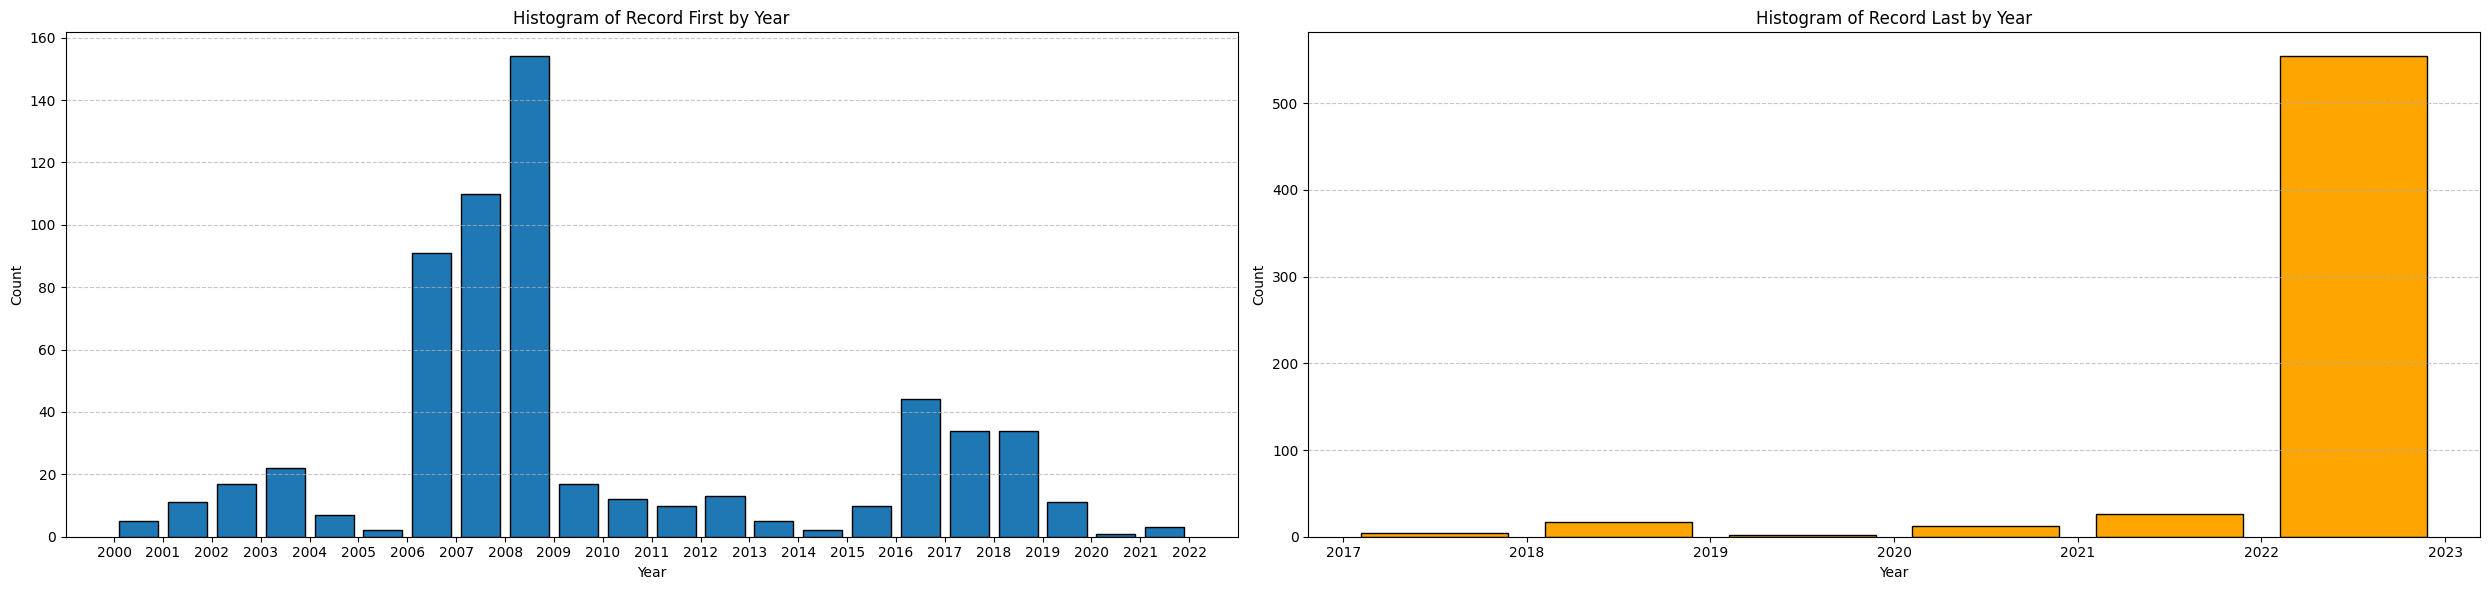

In [10]:
# Convert 'record_first' to datetime and extract the year
df_stations['record_first_year'] = pd.to_datetime(df_stations['record_first']).dt.year
df_stations['record_last_year'] = pd.to_datetime(df_stations['record_last']).dt.year

# Plot histograms side by side
plt.figure(figsize=(25, 6))

# Plot histogram with larger figure size and adjusted x-axis spacing
plt.subplot(1, 2, 1)
plt.hist(df_stations['record_first_year'], bins=range(df_stations['record_first_year'].min(), df_stations['record_first_year'].max() + 1), edgecolor='black', rwidth=0.8)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Histogram of Record First by Year')
plt.xticks(range(df_stations['record_first_year'].min(), df_stations['record_first_year'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)


# Plot histogram for record_last_year
plt.subplot(1, 2, 2)
plt.hist(df_stations['record_last_year'], bins=range(df_stations['record_last_year'].min(), df_stations['record_last_year'].max() + 1), edgecolor='black', rwidth=0.8, color='orange')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Histogram of Record Last by Year')
plt.xticks(range(df_stations['record_last_year'].min(), df_stations['record_last_year'].max() + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [11]:
# Stations dataframe
# Importing csv
stations = pd.read_csv(
    '../input/brazil-weather-information-by-inmet/stations.csv',
    decimal=',',
    parse_dates=['record_first', 'record_last']
)

stations['year_first'] = pd.DatetimeIndex(stations['record_first']).year

stations['year_last'] = pd.DatetimeIndex(stations['record_last']).year

stations['year_last_str'] = stations['year_last'].astype('object')

stations['station_on'] = stations['record_last'] == stations['record_last'].max()

# Stations geoplot
# Hoverdata
hover_map = {
    'state': True,
    'id_station': True,
    'lon': ':.4f',
    'lat': ':.4f',
    'year_first': True
}

fig = px.scatter_geo(stations,
                     lat='lat',
                     lon='lon',
                     symbol='station_on',
                     color='year_last_str',
                     hover_name='city_station',
                     hover_data=hover_map,
                     fitbounds="locations",
                     title="Location of Automatic Weather Stations in Brazil",
                     labels={
                            'year_last_str': 'Last Record Year',
                            'year_first': 'First Record Year',
                            'station_on': 'Station Online',
                            'state': 'State',
                            'id_station': 'ID',
                            'lat': 'Lat',
                            'lon': 'Lon'})

fig.show()

# Questão 1 - Tendências de Temperatura:
## Análise por região 

- ## Sudeste

In [12]:
se_df_sum.head()

,ESTACAO,DATA (YYYY-MM-DD),rain_max,rad_max,temp_avg,temp_max,temp_min,hum_max,hum_min,wind_max,wind_avg
542,A601,2000-05-07,0.0,549.0,22.233333,23.0,20.8,87.0,67.0,8.7,2.041667
543,A601,2000-05-08,0.0,1830.0,22.154167,26.5,19.7,93.0,58.0,5.3,0.979167
544,A601,2000-05-09,0.4,1475.0,21.900000,26.0,20.3,97.0,68.0,12.5,2.433333
545,A601,2000-05-10,0.0,2807.0,20.729167,26.5,15.1,97.0,41.0,12.5,2.075000
546,A601,2000-05-11,8.2,2521.0,20.350000,25.3,17.9,97.0,49.0,12.2,2.545833


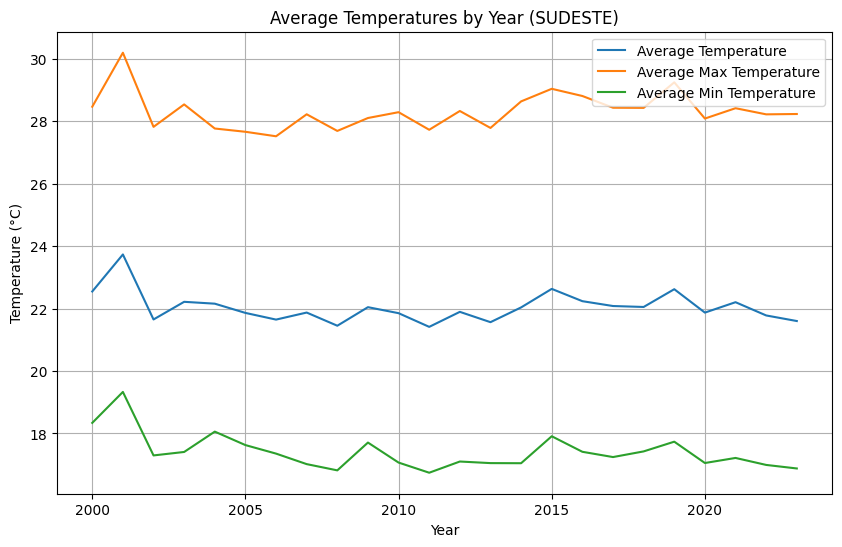

In [13]:
se_df_sum = se_df_sum.copy()
se_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(se_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
se_df_sum['Year'] = se_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average temperature for each year
se_average_temperature_by_year = se_df_sum.groupby('Year')['temp_avg'].mean()
se_avarage_max_temperature_by_year = se_df_sum.groupby('Year')['temp_max'].mean()
se_avarage_min_temperature_by_year = se_df_sum.groupby('Year')['temp_min'].mean()

# Plot the average temperatures by year
plt.figure(figsize=(10, 6))
plt.plot(se_average_temperature_by_year.index, se_average_temperature_by_year, label='Average Temperature')
plt.plot(se_avarage_max_temperature_by_year.index, se_avarage_max_temperature_by_year, label='Average Max Temperature')
plt.plot(se_avarage_min_temperature_by_year.index, se_avarage_min_temperature_by_year, label='Average Min Temperature')

plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Average Temperatures by Year (SUDESTE)')
plt.legend()
plt.grid(True)
plt.show()

- ## Sul

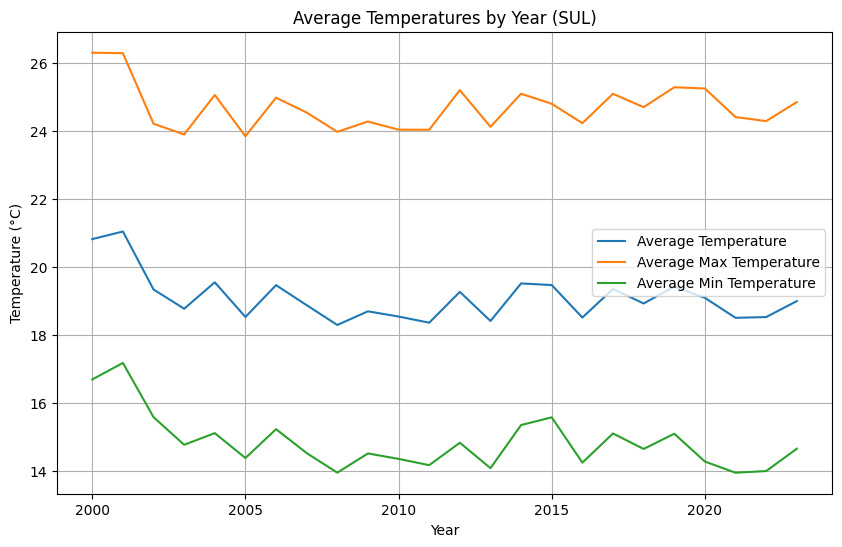

In [14]:
s_df_sum = s_df_sum.copy()
s_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(s_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
s_df_sum['Year'] = s_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average temperature for each year
s_average_temperature_by_year = s_df_sum.groupby('Year')['temp_avg'].mean()
s_avarage_max_temperature_by_year = s_df_sum.groupby('Year')['temp_max'].mean()
s_avarage_min_temperature_by_year = s_df_sum.groupby('Year')['temp_min'].mean()

# Plot the average temperatures by year
plt.figure(figsize=(10, 6))
plt.plot(s_average_temperature_by_year.index, s_average_temperature_by_year, label='Average Temperature')
plt.plot(s_avarage_max_temperature_by_year.index, s_avarage_max_temperature_by_year, label='Average Max Temperature')
plt.plot(s_avarage_min_temperature_by_year.index, s_avarage_min_temperature_by_year, label='Average Min Temperature')

plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Average Temperatures by Year (SUL)')
plt.legend()
plt.grid(True)
plt.show()

- ## Centro Oeste

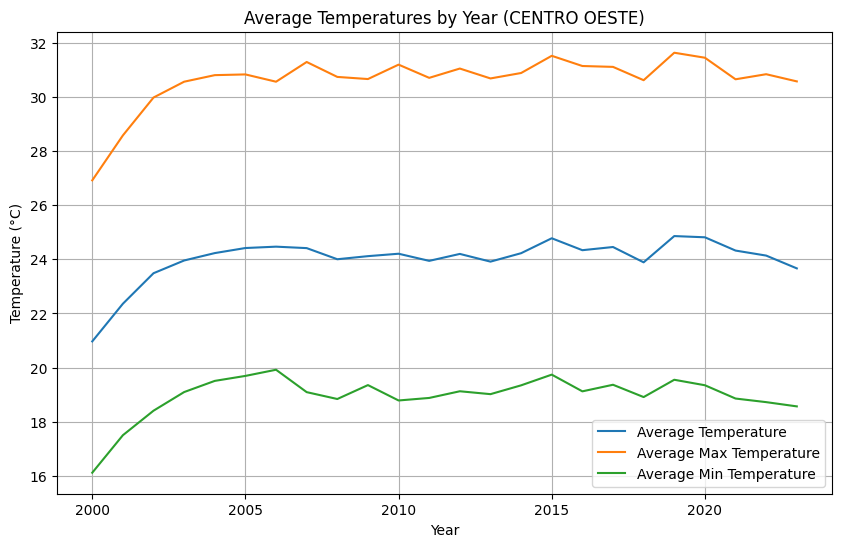

In [15]:
co_df_sum = co_df_sum.copy()
co_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(co_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
co_df_sum['Year'] = co_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average temperature for each year
co_average_temperature_by_year = co_df_sum.groupby('Year')['temp_avg'].mean()
co_avarage_max_temperature_by_year = co_df_sum.groupby('Year')['temp_max'].mean()
co_avarage_min_temperature_by_year = co_df_sum.groupby('Year')['temp_min'].mean()

# Plot the average temperatures by year
plt.figure(figsize=(10, 6))
plt.plot(co_average_temperature_by_year.index, co_average_temperature_by_year, label='Average Temperature')
plt.plot(co_avarage_max_temperature_by_year.index, co_avarage_max_temperature_by_year, label='Average Max Temperature')
plt.plot(co_avarage_min_temperature_by_year.index, co_avarage_min_temperature_by_year, label='Average Min Temperature')

plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Average Temperatures by Year (CENTRO OESTE)')
plt.legend()
plt.grid(True)
plt.show()

- ## Nordeste

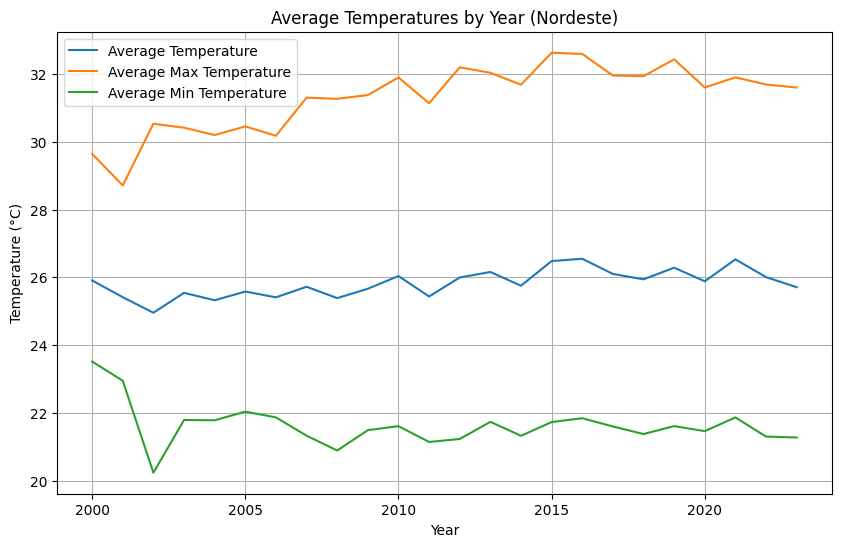

In [16]:
ne_df_sum = ne_df_sum.copy()
ne_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(ne_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
ne_df_sum['Year'] = ne_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average temperature for each year
ne_average_temperature_by_year = ne_df_sum.groupby('Year')['temp_avg'].mean()
ne_avarage_max_temperature_by_year = ne_df_sum.groupby('Year')['temp_max'].mean()
ne_avarage_min_temperature_by_year = ne_df_sum.groupby('Year')['temp_min'].mean()

# Plot the average temperatures by year
plt.figure(figsize=(10, 6))
plt.plot(ne_average_temperature_by_year.index, ne_average_temperature_by_year, label='Average Temperature')
plt.plot(ne_avarage_max_temperature_by_year.index, ne_avarage_max_temperature_by_year, label='Average Max Temperature')
plt.plot(ne_avarage_min_temperature_by_year.index, ne_avarage_min_temperature_by_year, label='Average Min Temperature')

plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Average Temperatures by Year (Nordeste)')
plt.legend()
plt.grid(True)
plt.show()

- ## Nordeste

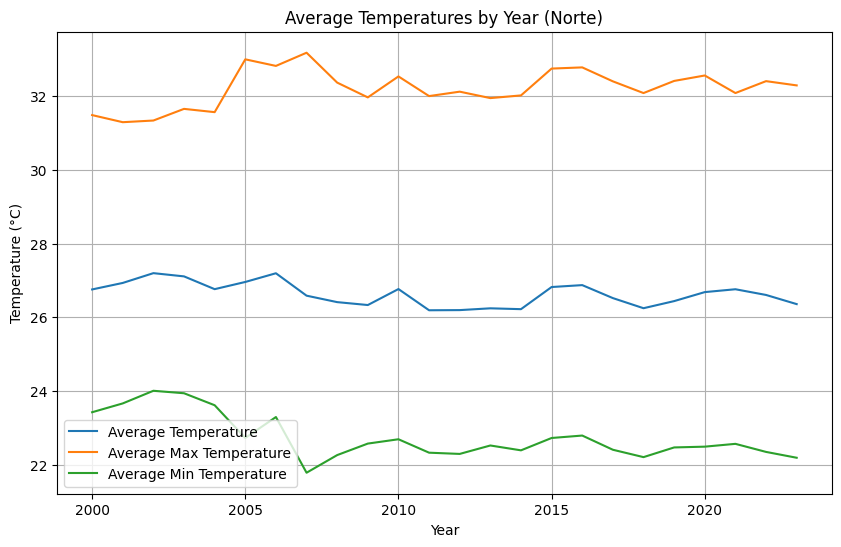

In [17]:
n_df_sum = n_df_sum.copy()
n_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(n_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
n_df_sum['Year'] = n_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average temperature for each year
n_average_temperature_by_year = n_df_sum.groupby('Year')['temp_avg'].mean()
n_avarage_max_temperature_by_year = n_df_sum.groupby('Year')['temp_max'].mean()
n_avarage_min_temperature_by_year = n_df_sum.groupby('Year')['temp_min'].mean()

# Plot the average temperatures by year
plt.figure(figsize=(10, 6))
plt.plot(n_average_temperature_by_year.index, n_average_temperature_by_year, label='Average Temperature')
plt.plot(n_avarage_max_temperature_by_year.index, n_avarage_max_temperature_by_year, label='Average Max Temperature')
plt.plot(n_avarage_min_temperature_by_year.index, n_avarage_min_temperature_by_year, label='Average Min Temperature')

plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Average Temperatures by Year (Norte)')
plt.legend()
plt.grid(True)
plt.show()

- ## Todas as regiões juntas

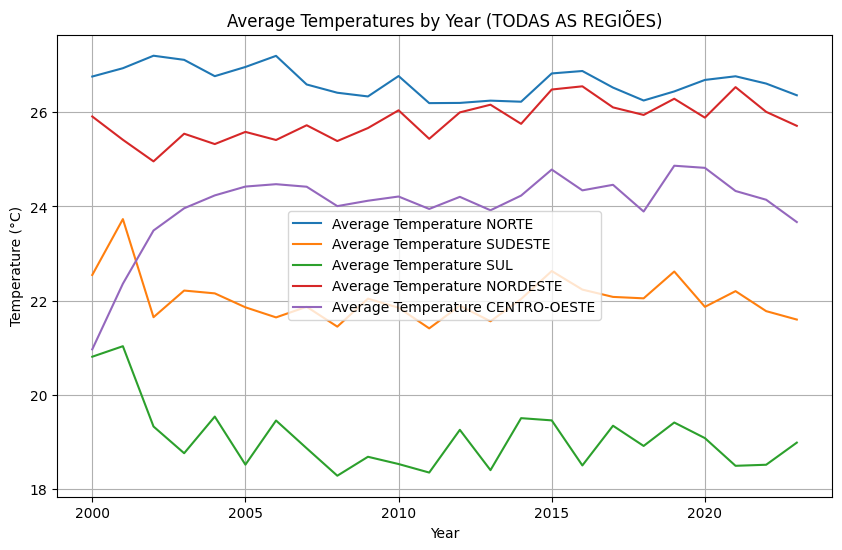

In [18]:
# Plot the average temperatures by year of all regions
plt.figure(figsize=(10, 6))
plt.plot(n_average_temperature_by_year.index, n_average_temperature_by_year, label='Average Temperature NORTE')
# plt.plot(n_avarage_max_temperature_by_year.index, n_avarage_max_temperature_by_year, label='Average Max Temperature NORTE')
# plt.plot(n_avarage_min_temperature_by_year.index, n_avarage_min_temperature_by_year, label='Average Min Temperature NORTE')

plt.plot(se_average_temperature_by_year.index, se_average_temperature_by_year, label='Average Temperature SUDESTE')
# plt.plot(se_avarage_max_temperature_by_year.index, se_avarage_max_temperature_by_year, label='Average Max Temperature SUDESTE')
# plt.plot(se_avarage_min_temperature_by_year.index, se_avarage_min_temperature_by_year, label='Average Min Temperature SUDESTE')

plt.plot(s_average_temperature_by_year.index, s_average_temperature_by_year, label='Average Temperature SUL')
# plt.plot(s_avarage_max_temperature_by_year.index, s_avarage_max_temperature_by_year, label='Average Max Temperature SUL')
# plt.plot(s_avarage_min_temperature_by_year.index, s_avarage_min_temperature_by_year, label='Average Min Temperature SUL')

plt.plot(ne_average_temperature_by_year.index, ne_average_temperature_by_year, label='Average Temperature NORDESTE')
# plt.plot(ne_avarage_max_temperature_by_year.index, ne_avarage_max_temperature_by_year, label='Average Max Temperature NORDESTE')
# plt.plot(ne_avarage_min_temperature_by_year.index, ne_avarage_min_temperature_by_year, label='Average Min Temperature NORDESTE')

plt.plot(co_average_temperature_by_year.index, co_average_temperature_by_year, label='Average Temperature CENTRO-OESTE')
# plt.plot(co_avarage_max_temperature_by_year.index, co_avarage_max_temperature_by_year, label='Average Max Temperature CENTRO-OESTE')
# plt.plot(co_avarage_min_temperature_by_year.index, co_avarage_min_temperature_by_year, label='Average Min Temperature CENTRO-OESTE')


plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Average Temperatures by Year (TODAS AS REGIÕES)')
plt.legend()
plt.grid(True)
plt.show()

# Questão 2 - Padrões de Precipitação:
## Análise por região

- ## Sudeste

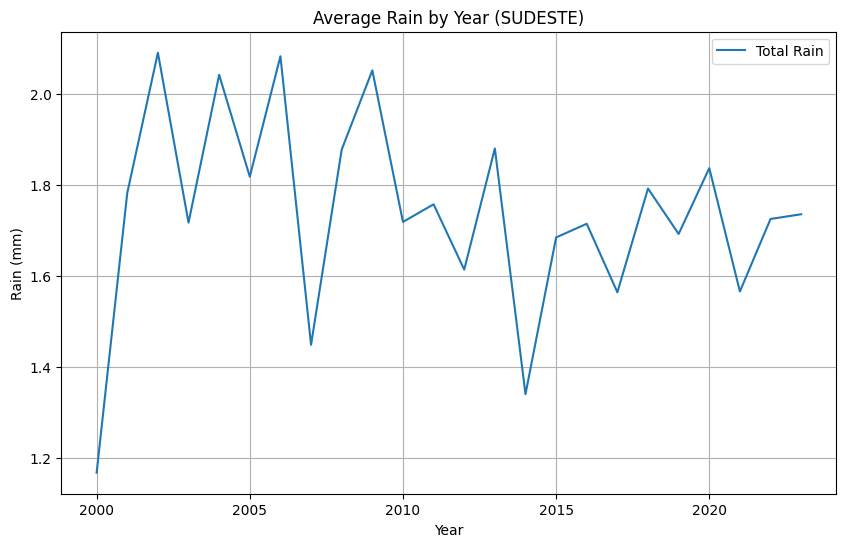

In [19]:
se_df_sum = se_df_sum.copy()
se_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(se_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
se_df_sum['Year'] = se_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average rain for each year
se_average_rain_by_year = se_df_sum.groupby('Year')['rain_max'].mean()

# Plot the Total rain by year
plt.figure(figsize=(10, 6))
plt.plot(se_average_rain_by_year.index, se_average_rain_by_year, label='Total Rain')

plt.xlabel('Year')
plt.ylabel('Rain (mm)')
plt.title('Average Rain by Year (SUDESTE)')
plt.legend()
plt.grid(True)
plt.show()

- ## Sul

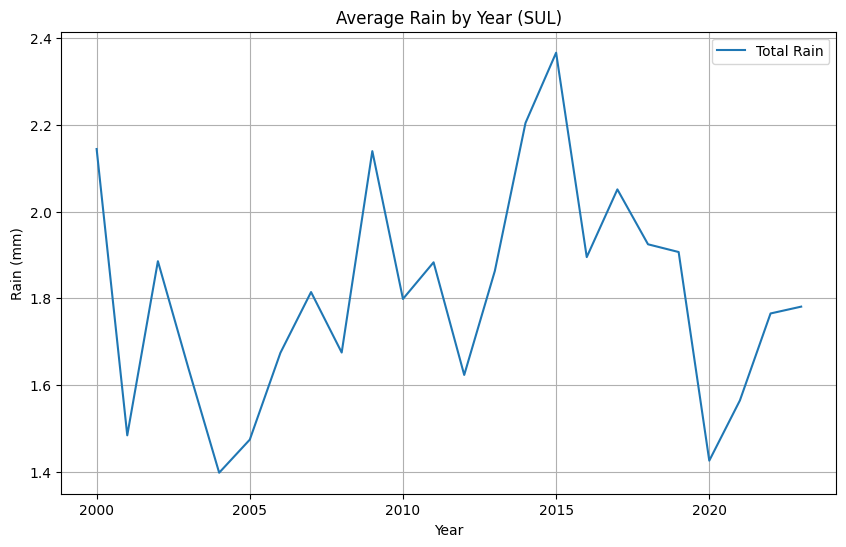

In [20]:
s_df_sum = s_df_sum.copy()
s_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(s_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
s_df_sum['Year'] = s_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average rain for each year
s_average_rain_by_year = s_df_sum.groupby('Year')['rain_max'].mean()

# Plot the Total rain by year
plt.figure(figsize=(10, 6))
plt.plot(s_average_rain_by_year.index, s_average_rain_by_year, label='Total Rain')

plt.xlabel('Year')
plt.ylabel('Rain (mm)')
plt.title('Average Rain by Year (SUL)')
plt.legend()
plt.grid(True)
plt.show()

- ## Centro Oeste

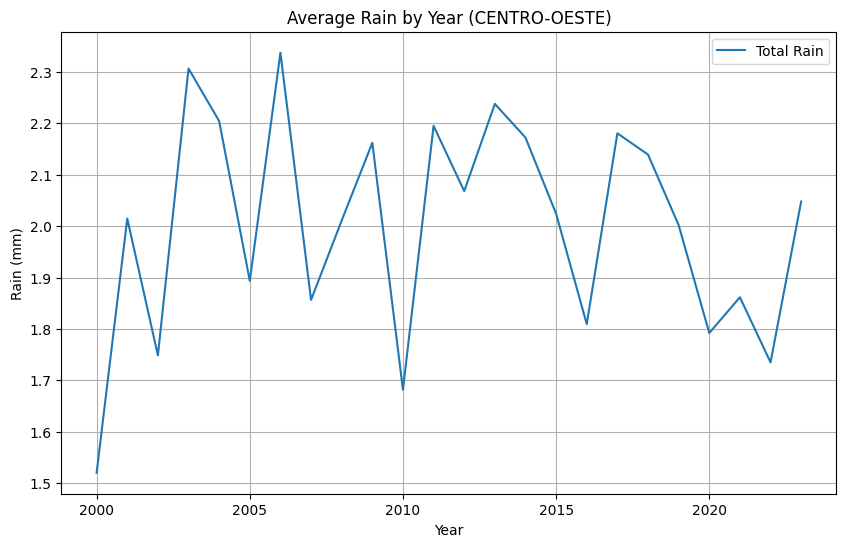

In [21]:
co_df_sum = co_df_sum.copy()
co_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(co_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
co_df_sum['Year'] = co_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average rain for each year
co_average_rain_by_year = co_df_sum.groupby('Year')['rain_max'].mean()

# Plot the average rain by year
plt.figure(figsize=(10, 6))
plt.plot(co_average_rain_by_year.index, co_average_rain_by_year, label='Total Rain')

plt.xlabel('Year')
plt.ylabel('Rain (mm)')
plt.title('Average Rain by Year (CENTRO-OESTE)')
plt.legend()
plt.grid(True)
plt.show()

- ## Norte

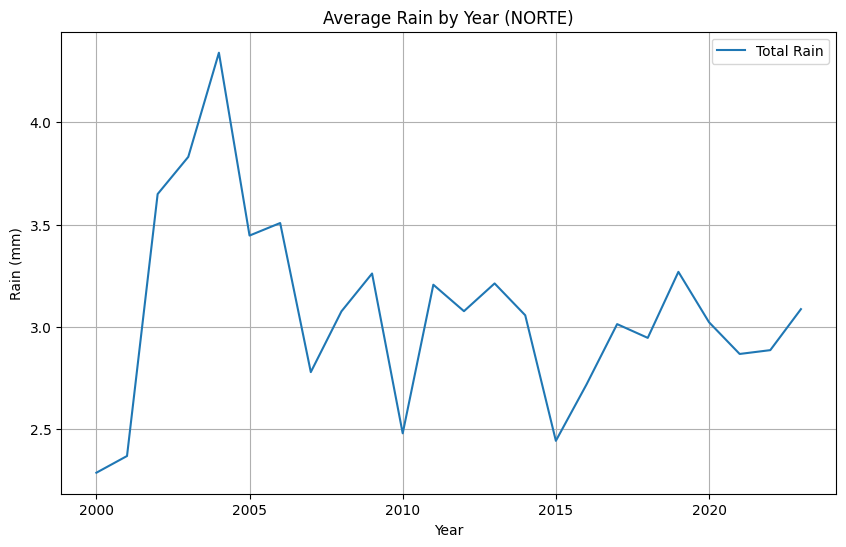

In [22]:
n_df_sum = n_df_sum.copy()
n_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(n_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
n_df_sum['Year'] = n_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average rain for each year
n_average_rain_by_year = n_df_sum.groupby('Year')['rain_max'].mean()

# Plot the average rain by year
plt.figure(figsize=(10, 6))
plt.plot(n_average_rain_by_year.index, n_average_rain_by_year, label='Total Rain')

plt.xlabel('Year')
plt.ylabel('Rain (mm)')
plt.title('Average Rain by Year (NORTE)')
plt.legend()
plt.grid(True)
plt.show()

- ## Nordeste

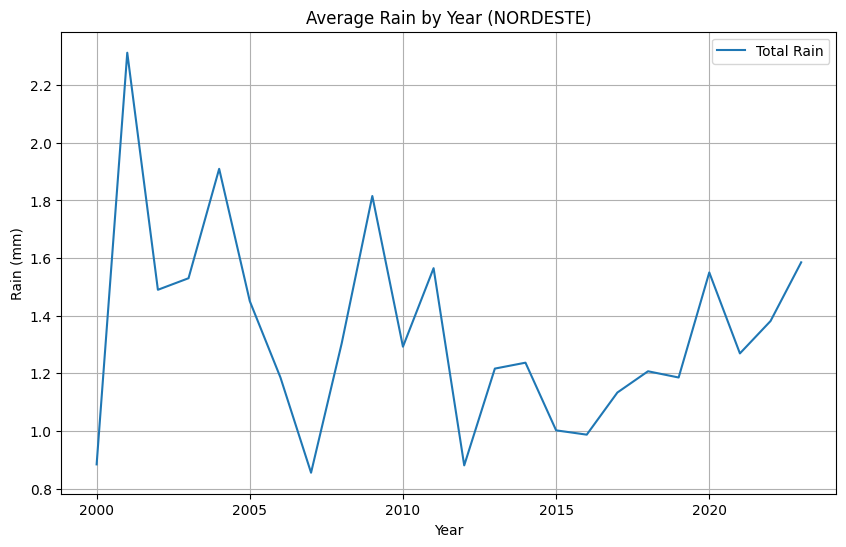

In [23]:
ne_df_sum = ne_df_sum.copy()
ne_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(ne_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
ne_df_sum['Year'] = ne_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average rain for each year
ne_average_rain_by_year = ne_df_sum.groupby('Year')['rain_max'].mean()

# Plot the average rain by year
plt.figure(figsize=(10, 6))
plt.plot(ne_average_rain_by_year.index, ne_average_rain_by_year, label='Total Rain')

plt.xlabel('Year')
plt.ylabel('Rain (mm)')
plt.title('Average Rain by Year (NORDESTE)')
plt.legend()
plt.grid(True)
plt.show()

- ## Todas as regiões juntas

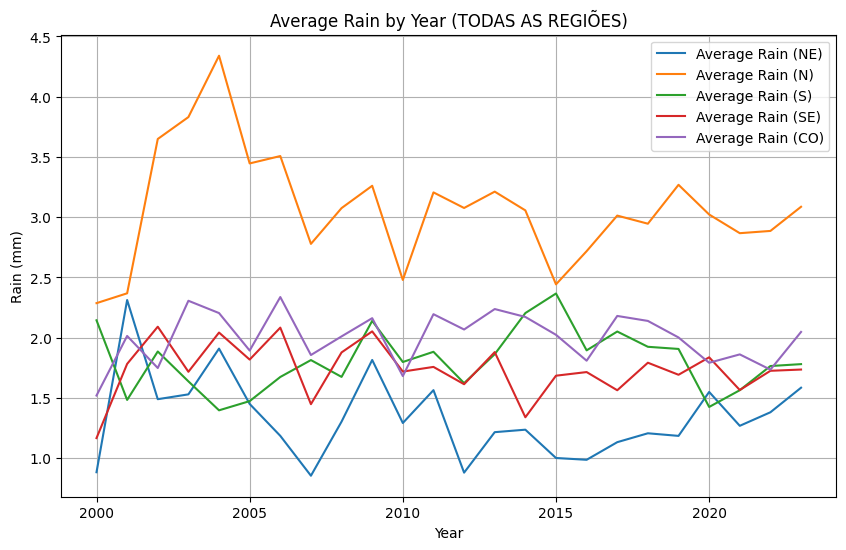

In [24]:
# Plot the Max rain by year
plt.figure(figsize=(10, 6))
plt.plot(ne_average_rain_by_year.index, ne_average_rain_by_year, label='Average Rain (NE)')
plt.plot(n_average_rain_by_year.index, n_average_rain_by_year, label='Average Rain (N)')
plt.plot(s_average_rain_by_year.index, s_average_rain_by_year, label='Average Rain (S)')
plt.plot(se_average_rain_by_year.index, se_average_rain_by_year, label='Average Rain (SE)')
plt.plot(co_average_rain_by_year.index, co_average_rain_by_year, label='Average Rain (CO)')

plt.xlabel('Year')
plt.ylabel('Rain (mm)')
plt.title('Average Rain by Year (TODAS AS REGIÕES)')
plt.legend()
plt.grid(True)
plt.show()

# Questão 3 - Correlação entre Precipitação e Temperatura:
## Análise por região

# 6. Análise Anual ou Mensal:

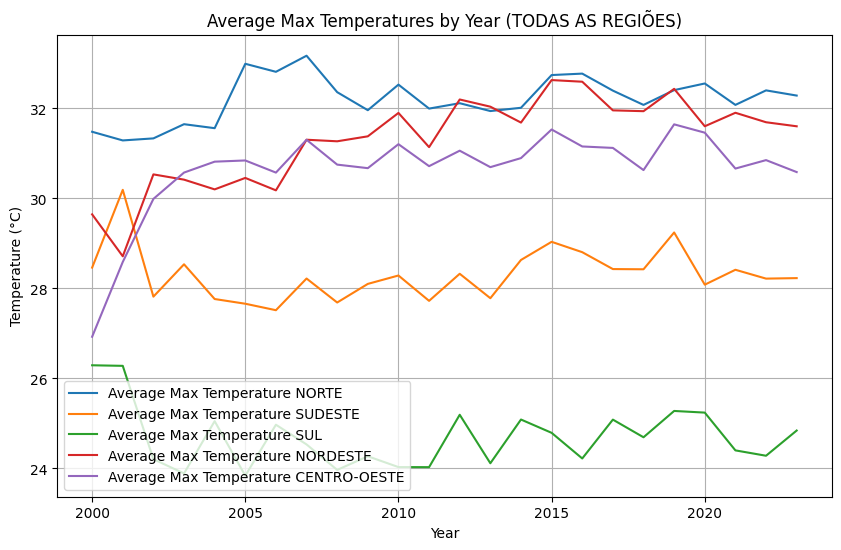

In [25]:
# Plot the maximum temperatures by year of all regions
plt.figure(figsize=(10, 6))
# plt.plot(n_average_temperature_by_year.index, n_average_temperature_by_year, label='Average Temperature NORTE')
plt.plot(n_avarage_max_temperature_by_year.index, n_avarage_max_temperature_by_year, label='Average Max Temperature NORTE')
# plt.plot(n_avarage_min_temperature_by_year.index, n_avarage_min_temperature_by_year, label='Average Min Temperature NORTE')

# plt.plot(se_average_temperature_by_year.index, se_average_temperature_by_year, label='Average Temperature SUDESTE')
plt.plot(se_avarage_max_temperature_by_year.index, se_avarage_max_temperature_by_year, label='Average Max Temperature SUDESTE')
# plt.plot(se_avarage_min_temperature_by_year.index, se_avarage_min_temperature_by_year, label='Average Min Temperature SUDESTE')

# plt.plot(s_average_temperature_by_year.index, s_average_temperature_by_year, label='Average Temperature SUL')
plt.plot(s_avarage_max_temperature_by_year.index, s_avarage_max_temperature_by_year, label='Average Max Temperature SUL')
# plt.plot(s_avarage_min_temperature_by_year.index, s_avarage_min_temperature_by_year, label='Average Min Temperature SUL')

# plt.plot(ne_average_temperature_by_year.index, ne_average_temperature_by_year, label='Average Temperature NORDESTE')
plt.plot(ne_avarage_max_temperature_by_year.index, ne_avarage_max_temperature_by_year, label='Average Max Temperature NORDESTE')
# plt.plot(ne_avarage_min_temperature_by_year.index, ne_avarage_min_temperature_by_year, label='Average Min Temperature NORDESTE')

# plt.plot(co_average_temperature_by_year.index, co_average_temperature_by_year, label='Average Temperature CENTRO-OESTE')
plt.plot(co_avarage_max_temperature_by_year.index, co_avarage_max_temperature_by_year, label='Average Max Temperature CENTRO-OESTE')
# plt.plot(co_avarage_min_temperature_by_year.index, co_avarage_min_temperature_by_year, label='Average Min Temperature CENTRO-OESTE')


plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Average Max Temperatures by Year (TODAS AS REGIÕES)')
plt.legend()
plt.grid(True)
plt.show()

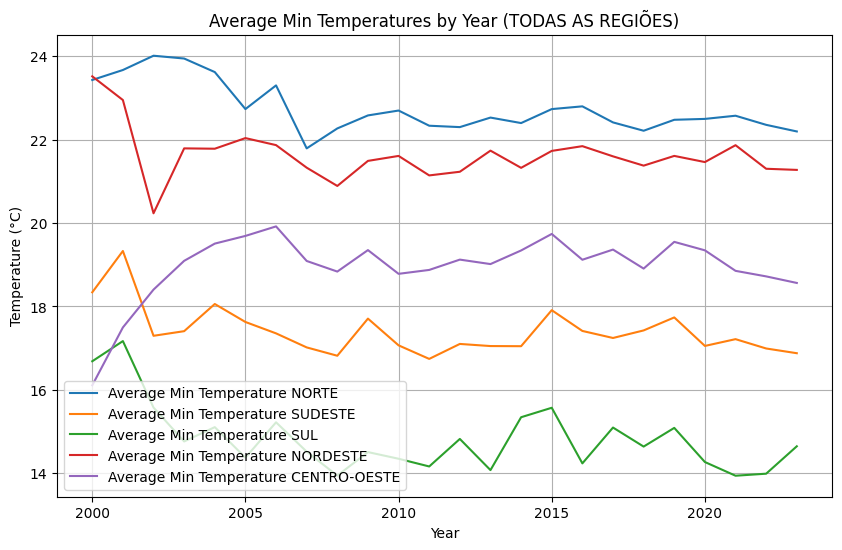

In [26]:
# Plot the average temperatures by year of all regions
plt.figure(figsize=(10, 6))
# plt.plot(n_average_temperature_by_year.index, n_average_temperature_by_year, label='Average Temperature NORTE')
# plt.plot(n_avarage_max_temperature_by_year.index, n_avarage_max_temperature_by_year, label='Average Max Temperature NORTE')
plt.plot(n_avarage_min_temperature_by_year.index, n_avarage_min_temperature_by_year, label='Average Min Temperature NORTE')

# plt.plot(se_average_temperature_by_year.index, se_average_temperature_by_year, label='Average Temperature SUDESTE')
# plt.plot(se_avarage_max_temperature_by_year.index, se_avarage_max_temperature_by_year, label='Average Max Temperature SUDESTE')
plt.plot(se_avarage_min_temperature_by_year.index, se_avarage_min_temperature_by_year, label='Average Min Temperature SUDESTE')

# plt.plot(s_average_temperature_by_year.index, s_average_temperature_by_year, label='Average Temperature SUL')
# plt.plot(s_avarage_max_temperature_by_year.index, s_avarage_max_temperature_by_year, label='Average Max Temperature SUL')
plt.plot(s_avarage_min_temperature_by_year.index, s_avarage_min_temperature_by_year, label='Average Min Temperature SUL')

# plt.plot(ne_average_temperature_by_year.index, ne_average_temperature_by_year, label='Average Temperature NORDESTE')
# plt.plot(ne_avarage_max_temperature_by_year.index, ne_avarage_max_temperature_by_year, label='Average Max Temperature NORDESTE')
plt.plot(ne_avarage_min_temperature_by_year.index, ne_avarage_min_temperature_by_year, label='Average Min Temperature NORDESTE')

# plt.plot(co_average_temperature_by_year.index, co_average_temperature_by_year, label='Average Temperature CENTRO-OESTE')
# plt.plot(co_avarage_max_temperature_by_year.index, co_avarage_max_temperature_by_year, label='Average Max Temperature CENTRO-OESTE')
plt.plot(co_avarage_min_temperature_by_year.index, co_avarage_min_temperature_by_year, label='Average Min Temperature CENTRO-OESTE')


plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Average Min Temperatures by Year (TODAS AS REGIÕES)')
plt.legend()
plt.grid(True)
plt.show()

# Questão 7 - Eventos Climáticos Extremos:

## Intensidade de chuva

Consoante a intensidade (ou taxa) da precipitação, esta é qualificada da seguinte forma:[10]

- Chuva fraca: quando a intensidade é inferior a 2,5 milímetros por hora (mm/h);
- Chuva moderada: quando a intensidade é igual ou superior a 2,5 mm/h mas inferior a 10 mm/h;
- Chuva forte: quando a intensidade é igual ou superior a 10 mm/h mas inferior a 50 mm/h;
- Chuva violenta: quando a intensidade é superior a 50 mm/h (geralmente sob a forma de aguaceiros).

(fonte: https://pt.wikipedia.org/wiki/Chuva)

In [27]:
# a partir dos valores acima definimos as constantes
WEAK_RAIN_IN_MM = (0.1, 2.5)
MODERATE_RAIN_IN_MM = (2.51, 10)
STRONG_RAIN_IN_MM = (10.01, 50)
VIOLENT_RAIN_IN_MM = (50.01, 9999) # 9999 Representa o `infinito` 
HAS_RAINED = (0.1, 9999) # All possible values of rain

## Pegando todos os valores de chuva

In [28]:
columns_of_value = ['ESTACAO', 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)', 'DATA (YYYY-MM-DD)']
rain_filtered_df_2000 = df_2000[columns_of_value].dropna()
rain_filtered_df_2000 = rain_filtered_df_2000[(rain_filtered_df_2000['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2000['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2001 = df_2001[columns_of_value].dropna()
rain_filtered_df_2001 = rain_filtered_df_2001[(rain_filtered_df_2001['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2001['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2002 = df_2002[columns_of_value].dropna()
rain_filtered_df_2002 = rain_filtered_df_2002[(rain_filtered_df_2002['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2002['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2003 = df_2003[columns_of_value].dropna()
rain_filtered_df_2003 = rain_filtered_df_2003[(rain_filtered_df_2003['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2003['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2004 = df_2004[columns_of_value].dropna()
rain_filtered_df_2004 = rain_filtered_df_2004[(rain_filtered_df_2004['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2004['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2005 = df_2005[columns_of_value].dropna()
rain_filtered_df_2005 = rain_filtered_df_2005[(rain_filtered_df_2005['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2005['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2006 = df_2006[columns_of_value].dropna()
rain_filtered_df_2006 = rain_filtered_df_2006[(rain_filtered_df_2006['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2006['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2007 = df_2007[columns_of_value].dropna()
rain_filtered_df_2007 = rain_filtered_df_2007[(rain_filtered_df_2007['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2007['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2008 = df_2008[columns_of_value].dropna()
rain_filtered_df_2008 = rain_filtered_df_2008[(rain_filtered_df_2008['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2008['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2009 = df_2009[columns_of_value].dropna()
rain_filtered_df_2009 = rain_filtered_df_2009[(rain_filtered_df_2009['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2009['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2010 = df_2010[columns_of_value].dropna()
rain_filtered_df_2010 = rain_filtered_df_2010[(rain_filtered_df_2010['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2010['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2011 = df_2011[columns_of_value].dropna()
rain_filtered_df_2011 = rain_filtered_df_2011[(rain_filtered_df_2011['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2011['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2012 = df_2012[columns_of_value].dropna()
rain_filtered_df_2012 = rain_filtered_df_2012[(rain_filtered_df_2012['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2012['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2013 = df_2013[columns_of_value].dropna()
rain_filtered_df_2013 = rain_filtered_df_2013[(rain_filtered_df_2013['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2013['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2014 = df_2014[columns_of_value].dropna()
rain_filtered_df_2014 = rain_filtered_df_2014[(rain_filtered_df_2014['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2014['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2015 = df_2015[columns_of_value].dropna()
rain_filtered_df_2015 = rain_filtered_df_2015[(rain_filtered_df_2015['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2015['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2016 = df_2016[columns_of_value].dropna()
rain_filtered_df_2016 = rain_filtered_df_2016[(rain_filtered_df_2016['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2016['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2017 = df_2017[columns_of_value].dropna()
rain_filtered_df_2017 = rain_filtered_df_2017[(rain_filtered_df_2017['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2017['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2018 = df_2018[columns_of_value].dropna()
rain_filtered_df_2018 = rain_filtered_df_2018[(rain_filtered_df_2018['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2018['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2019 = df_2019[columns_of_value].dropna()
rain_filtered_df_2019 = rain_filtered_df_2019[(rain_filtered_df_2019['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2019['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2020 = df_2020[columns_of_value].dropna()
rain_filtered_df_2020 = rain_filtered_df_2020[(rain_filtered_df_2020['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2020['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2021 = df_2021[columns_of_value].dropna()
rain_filtered_df_2021 = rain_filtered_df_2021[(rain_filtered_df_2021['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2021['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2022 = df_2022[columns_of_value].dropna()
rain_filtered_df_2022 = rain_filtered_df_2022[(rain_filtered_df_2022['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2022['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

rain_filtered_df_2023 = df_2023[columns_of_value].dropna()
rain_filtered_df_2023 = rain_filtered_df_2023[(rain_filtered_df_2023['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] >= 0.1) &
                          (rain_filtered_df_2023['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] <= 9999)]

### Definindo um df com todos as horas de chuvas registradas entre 2000 e 2023

In [29]:
all_rain_df = pd.concat([rain_filtered_df_2000, rain_filtered_df_2001, rain_filtered_df_2002,
                        rain_filtered_df_2003, rain_filtered_df_2004, rain_filtered_df_2005,
                        rain_filtered_df_2006, rain_filtered_df_2007, rain_filtered_df_2008,
                        rain_filtered_df_2009, rain_filtered_df_2010, rain_filtered_df_2011,
                        rain_filtered_df_2012, rain_filtered_df_2013, rain_filtered_df_2014,
                        rain_filtered_df_2015, rain_filtered_df_2016, rain_filtered_df_2017,
                        rain_filtered_df_2018, rain_filtered_df_2019, rain_filtered_df_2020,
                        rain_filtered_df_2021, rain_filtered_df_2022, rain_filtered_df_2023])

In [30]:
all_rain_df

,ESTACAO,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)",DATA (YYYY-MM-DD)
1921,A001,0.2,2000-07-26
2740,A001,0.2,2000-08-29
2741,A001,0.6,2000-08-29
2743,A001,0.2,2000-08-29
2744,A001,5.6,2000-08-29
...,...,...,...
3312309,A898,0.2,2023-08-20
3312315,A898,0.2,2023-08-21
3312408,A898,4.8,2023-08-25
3312412,A898,0.2,2023-08-25


### Verificando quanto chuvas de cada tipo tivemos em todos esses anos

In [31]:
# Check how many rows are within each range
weak_rain_count = all_rain_df[all_rain_df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].between(*WEAK_RAIN_IN_MM)].shape[0]
moderate_rain_count = all_rain_df[all_rain_df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].between(*MODERATE_RAIN_IN_MM)].shape[0]
strong_rain_count = all_rain_df[all_rain_df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].between(*STRONG_RAIN_IN_MM)].shape[0]
violent_rain_count = all_rain_df[all_rain_df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].between(*VIOLENT_RAIN_IN_MM)].shape[0]

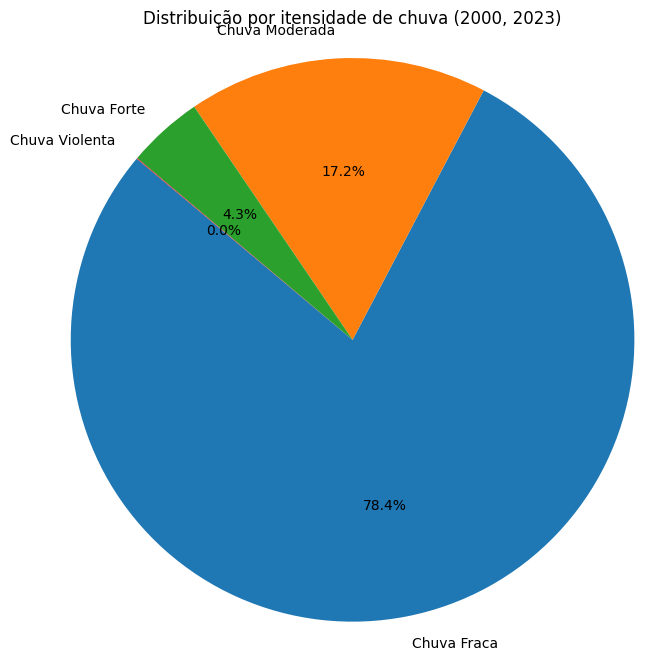

In [32]:
# Assuming you have the rain counts
labels = ['Chuva Fraca', 'Chuva Moderada', 'Chuva Forte', 'Chuva Violenta']
counts = [weak_rain_count, moderate_rain_count, strong_rain_count, violent_rain_count]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição por itensidade de chuva (2000, 2023)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Show the pie chart
plt.show()

### Fazendo a mesma análise por região

In [33]:
def get_rain_counts_in_df(df):
    WEAK_RAIN_IN_MM = (0.1, 2.5)
    MODERATE_RAIN_IN_MM = (2.51, 10)
    STRONG_RAIN_IN_MM = (10.01, 50)
    VIOLENT_RAIN_IN_MM = (50.01, 9999) # 9999 Representa o `infinito` 

    weak_rain_count = df[df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].between(*WEAK_RAIN_IN_MM)].shape[0]
    moderate_rain_count = df[df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].between(*MODERATE_RAIN_IN_MM)].shape[0]
    strong_rain_count = df[df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].between(*STRONG_RAIN_IN_MM)].shape[0]
    violent_rain_count = df[df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'].between(*VIOLENT_RAIN_IN_MM)].shape[0]    

    return weak_rain_count, moderate_rain_count, strong_rain_count, violent_rain_count


# Df's das chuvas separados por regiões
se_df_rain = all_rain_df[all_rain_df['ESTACAO'].isin(se_stations)]
s_df_rain = all_rain_df[all_rain_df['ESTACAO'].isin(s_stations)]
co_df_rain = all_rain_df[all_rain_df['ESTACAO'].isin(co_stations)]
n_df_rain = all_rain_df[all_rain_df['ESTACAO'].isin(n_stations)]
ne_df_rain = all_rain_df[all_rain_df['ESTACAO'].isin(ne_stations)]


se_weak_rain_count, se_moderate_rain_count, se_strong_rain_count, se_violent_rain_count = get_rain_counts_in_df(se_df_rain)
s_weak_rain_count, s_moderate_rain_count, s_strong_rain_count, s_violent_rain_count = get_rain_counts_in_df(s_df_rain)
co_weak_rain_count, co_moderate_rain_count, co_strong_rain_count, co_violent_rain_count = get_rain_counts_in_df(co_df_rain)
n_weak_rain_count, n_moderate_rain_count, n_strong_rain_count, n_violent_rain_count = get_rain_counts_in_df(n_df_rain)
ne_weak_rain_count, ne_moderate_rain_count, ne_strong_rain_count, ne_violent_rain_count = get_rain_counts_in_df(ne_df_rain)

# Combine the counts for each region
weak_counts = [se_weak_rain_count, s_weak_rain_count, co_weak_rain_count, n_weak_rain_count, ne_weak_rain_count]
moderate_counts = [se_moderate_rain_count, s_moderate_rain_count, co_moderate_rain_count, n_moderate_rain_count, ne_moderate_rain_count]
strong_counts = [se_strong_rain_count, s_strong_rain_count, co_strong_rain_count, n_strong_rain_count, ne_strong_rain_count]
violent_counts = [se_violent_rain_count, s_violent_rain_count, co_violent_rain_count, n_violent_rain_count, ne_violent_rain_count]
# Calculate the total count for each region
total_counts = [se_weak_rain_count + se_moderate_rain_count + se_strong_rain_count + se_violent_rain_count,
                s_weak_rain_count + s_moderate_rain_count + s_strong_rain_count + s_violent_rain_count,
                co_weak_rain_count + co_moderate_rain_count + co_strong_rain_count + co_violent_rain_count,
                n_weak_rain_count + n_moderate_rain_count + n_strong_rain_count + n_violent_rain_count,
                ne_weak_rain_count + ne_moderate_rain_count + ne_strong_rain_count + ne_violent_rain_count]

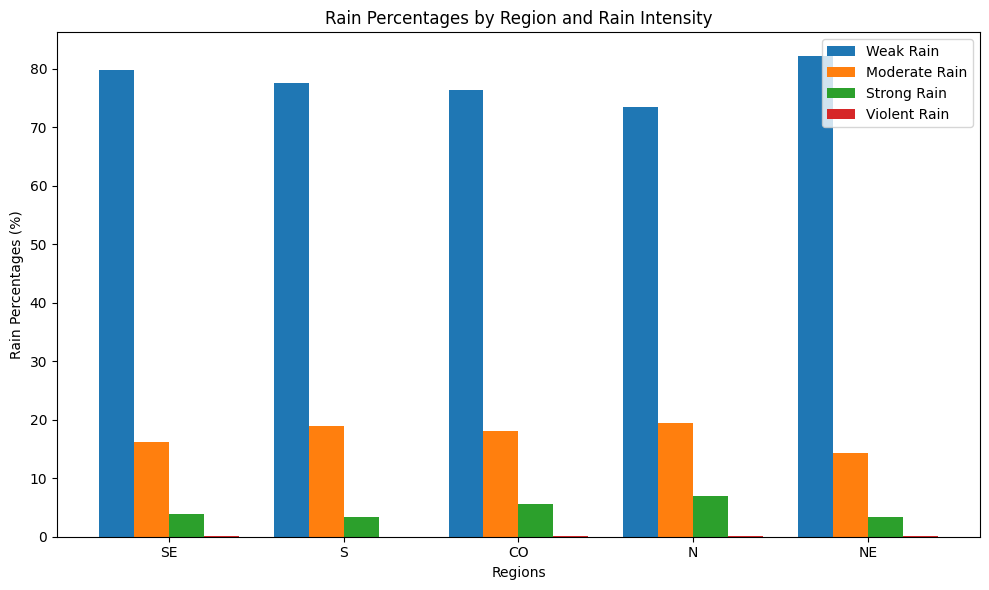

In [34]:
# Calculate the percentages
weak_percentages = [count / total * 100 for count, total in zip(weak_counts, total_counts)]
moderate_percentages = [count / total * 100 for count, total in zip(moderate_counts, total_counts)]
strong_percentages = [count / total * 100 for count, total in zip(strong_counts, total_counts)]
violent_percentages = [count / total * 100 for count, total in zip(violent_counts, total_counts)]

# Labels for each region
regions = ['SE', 'S', 'CO', 'N', 'NE']


# Plotting
width = 0.2  # Width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

bar1 = ax.bar(range(len(regions)), weak_percentages, width, label='Weak Rain')
bar2 = ax.bar([p + width for p in range(len(regions))], moderate_percentages, width, label='Moderate Rain')
bar3 = ax.bar([p + 2 * width for p in range(len(regions))], strong_percentages, width, label='Strong Rain')
bar4 = ax.bar([p + 3 * width for p in range(len(regions))], violent_percentages, width, label='Violent Rain')

ax.set_xlabel('Regions')
ax.set_ylabel('Rain Percentages (%)')
ax.set_title('Rain Percentages by Region and Rain Intensity')
ax.set_xticks([p + 1.5 * width for p in range(len(regions))])
ax.set_xticklabels(regions)
ax.legend()

plt.tight_layout()
plt.show()

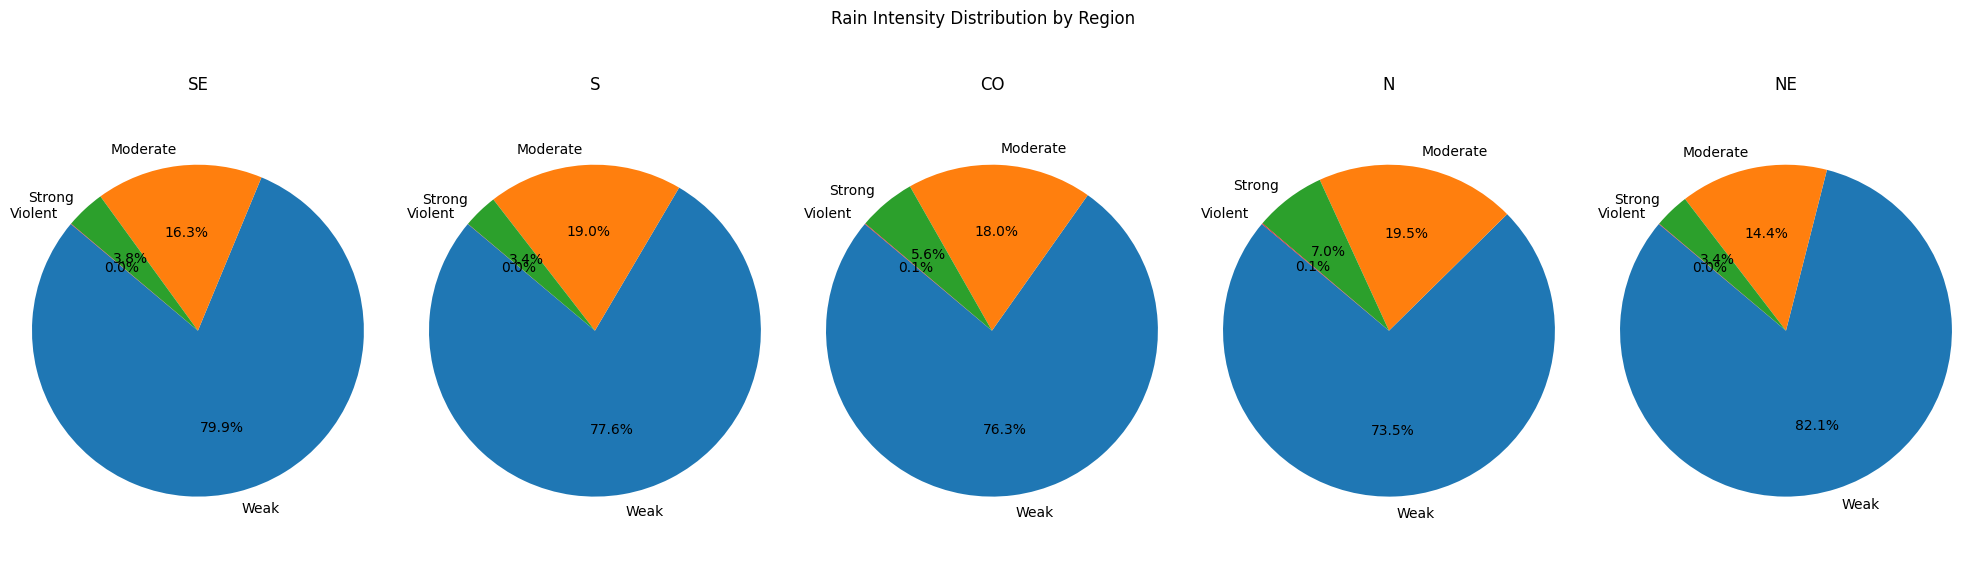

In [35]:


# Calculate the total count for each region
total_counts = [se_weak_rain_count + se_moderate_rain_count + se_strong_rain_count + se_violent_rain_count,
                s_weak_rain_count + s_moderate_rain_count + s_strong_rain_count + s_violent_rain_count,
                co_weak_rain_count + co_moderate_rain_count + co_strong_rain_count + co_violent_rain_count,
                n_weak_rain_count + n_moderate_rain_count + n_strong_rain_count + n_violent_rain_count,
                ne_weak_rain_count + ne_moderate_rain_count + ne_strong_rain_count + ne_violent_rain_count]

# Calculate the percentages
weak_percentages = [count / total * 100 for count, total in zip(weak_counts, total_counts)]
moderate_percentages = [count / total * 100 for count, total in zip(moderate_counts, total_counts)]
strong_percentages = [count / total * 100 for count, total in zip(strong_counts, total_counts)]
violent_percentages = [count / total * 100 for count, total in zip(violent_counts, total_counts)]

# Labels for each region
regions = ['SE', 'S', 'CO', 'N', 'NE']

# Plotting pie charts for each region
fig, axs = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle('Rain Intensity Distribution by Region')

for i in range(len(regions)):
    ax = axs[i]
    ax.pie([weak_percentages[i], moderate_percentages[i], strong_percentages[i], violent_percentages[i]],
           labels=['Weak', 'Moderate', 'Strong', 'Violent'],
           autopct='%1.1f%%', startangle=140)
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    ax.set_title(regions[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Analisando apenas as chuvas violentas, já que nos outros gráficos é tão pequeno que não dá para tirar muita coisa

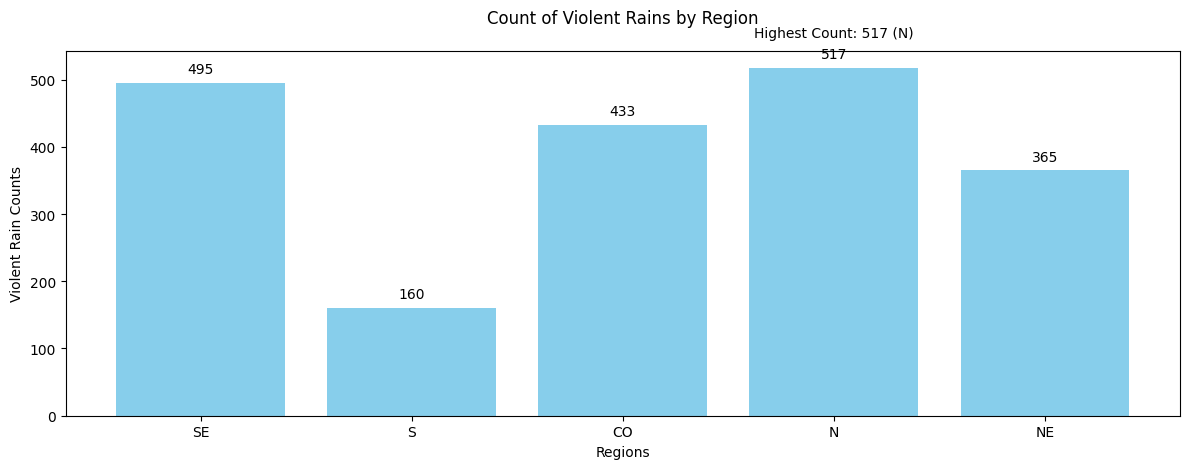

In [36]:
# Calculate the total count for each region
violent_counts = [se_violent_rain_count, s_violent_rain_count, co_violent_rain_count, n_violent_rain_count, ne_violent_rain_count]

# Labels for each region
regions = ['SE', 'S', 'CO', 'N', 'NE']

# Find the region with the maximum count of violent rains
max_violent_count = max(violent_counts)
max_violent_region = regions[violent_counts.index(max_violent_count)]

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

bar = ax.bar(range(len(regions)), violent_counts, color='skyblue')
ax.set_xlabel('Regions')
ax.set_ylabel('Violent Rain Counts')
ax.set_title('Count of Violent Rains by Region', pad=20)  # Add padding to the title
ax.set_xticks(range(len(regions)))
ax.set_xticklabels(regions)

# Annotate the region with the highest count
annotation_y = max_violent_count + 20  # Adjust the y position of the annotation
ax.annotate(f'Highest Count: {max_violent_count} ({max_violent_region})',
            xy=(violent_counts.index(max_violent_count), max_violent_count),
            xytext=(0, 20),  # Offset the annotation by 20 points
            textcoords='offset points',
            ha='center', va='bottom')

# Adding data labels on top of the bars
for i, count in enumerate(violent_counts):
    ax.text(i, count + 10, str(count), ha='center', va='bottom')

plt.tight_layout(rect=[0, 0.1, 1, 0.9])  # Adjust the layout to provide space for the title and annotation
plt.show()

### Quais estações do ano possuem mais chuvas perigosas (fortes e violentas)?

# Questão 8

Variação das Condições Climáticas nas Estações do Ano:

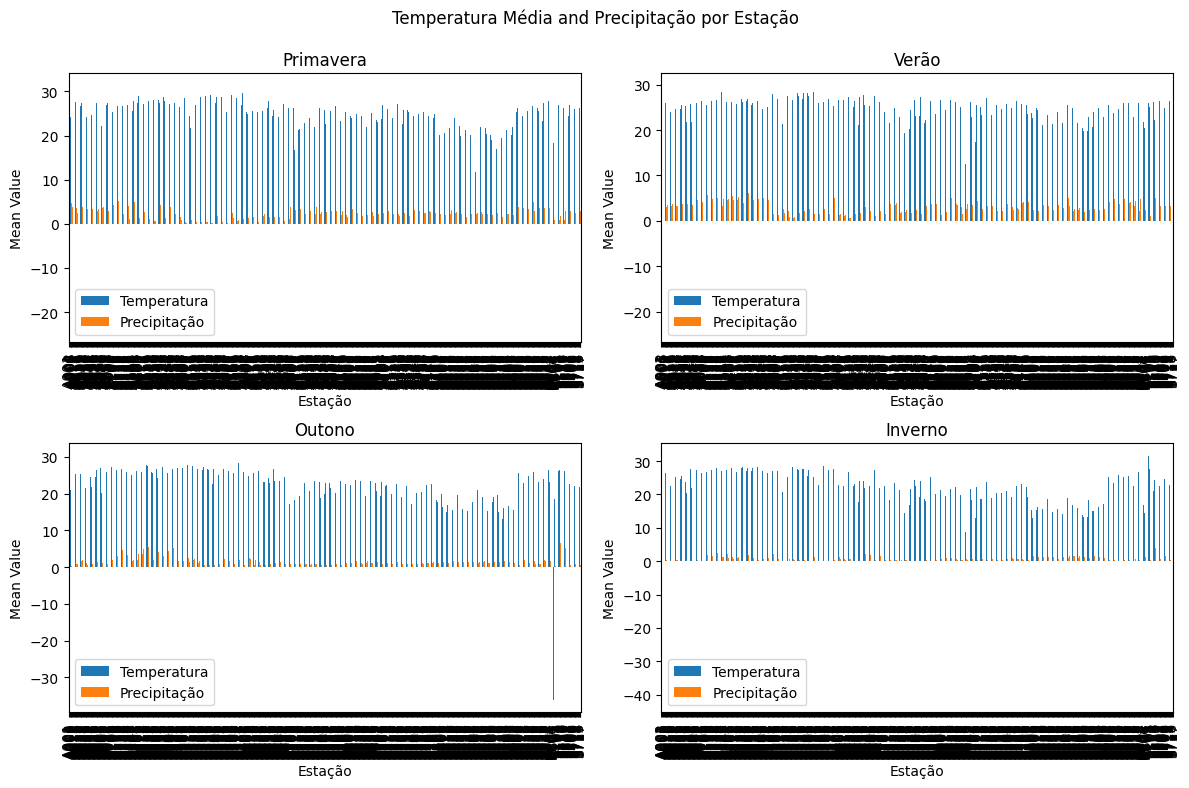

In [37]:
# Convert the 'DATA (YYYY-MM-DD)' column to a datetime object
all_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(all_df_sum['DATA (YYYY-MM-DD)'])

# Extract the month from the date
all_df_sum['Month'] = all_df_sum['DATA (YYYY-MM-DD)'].dt.month

# Create DataFrames for each season
spring_df = all_df_sum[all_df_sum['Month'].isin([10, 11, 12])]
summer_df = all_df_sum[all_df_sum['Month'].isin([1, 2, 3])]
autumn_df = all_df_sum[all_df_sum['Month'].isin([4, 5, 6])]
winter_df = all_df_sum[all_df_sum['Month'].isin([7, 8, 9])]

# Group the DataFrames by season and calculate the mean temperature and precipitation
seasons_data = {
    'Primavera': spring_df.groupby('ESTACAO').agg({'temp_avg': 'mean', 'rain_max': 'mean'}),
    'Verão': summer_df.groupby('ESTACAO').agg({'temp_avg': 'mean', 'rain_max': 'mean'}),
    'Outono': autumn_df.groupby('ESTACAO').agg({'temp_avg': 'mean', 'rain_max': 'mean'}),
    'Inverno': winter_df.groupby('ESTACAO').agg({'temp_avg': 'mean', 'rain_max': 'mean'})
}

# Create a bar chart for average temperature and precipitation
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle('Temperatura Média and Precipitação por Estação')

for i, (season, data) in enumerate(seasons_data.items()):
    ax = axes[i // 2, i % 2]
    data.plot(kind='bar', ax=ax)
    ax.set_title(season)
    ax.set_xlabel('Estação')
    ax.set_ylabel('Mean Value')
    ax.legend(['Temperatura', 'Precipitação'])

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# -------------------------- ESPAÇO PARA TESTES ---------------------------

In [38]:
# Sort the DataFrame by "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)" in descending order
df_2021_sorted = df_2021.sort_values(by="PRECIPITAÇÃO TOTAL, HORÁRIO (mm)", ascending=False)

df_2021_sorted.head(40)

,DATA (YYYY-MM-DD),Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (KJ/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",ESTACAO
2611864,2021-02-27,1600 UTC,88.8,1006.9,1007.7,1006.8,NaN,22.5,20.7,30.6,22.5,23.0,20.6,90.0,61.0,90.0,210.0,14.5,6.6,A226
2611851,2021-02-27,0300 UTC,86.4,1007.4,1008.2,1007.4,NaN,24.9,22.7,25.6,24.6,23.1,22.0,87.0,85.0,87.0,118.0,5.3,0.0,A226
2618724,2021-12-10,1200 UTC,85.6,1006.0,1006.2,1005.7,NaN,30.9,23.6,31.0,28.3,24.6,23.2,76.0,65.0,65.0,53.0,7.4,0.3,A226
3952879,2021-03-30,0700 UTC,85.0,1010.3,1011.0,1009.1,1.1,21.9,21.0,22.1,20.9,21.2,19.7,94.0,89.0,94.0,231.0,14.2,3.2,A667
2526070,2021-05-13,2200 UTC,76.6,1009.2,1010.0,1007.5,12.5,23.0,22.9,27.5,22.7,25.8,22.7,100.0,88.0,100.0,119.0,13.9,2.4,A201
2743151,2021-02-22,2300 UTC,75.2,984.7,984.7,983.5,NaN,22.7,22.2,22.8,22.4,22.3,21.3,98.0,92.0,97.0,NaN,NaN,NaN,A247
3863400,2021-01-11,0000 UTC,74.6,978.1,978.3,976.9,NaN,22.3,22.3,23.1,22.3,23.1,22.3,100.0,100.0,100.0,280.0,6.9,1.3,A625
649077,2021-02-04,2100 UTC,74.2,968.1,968.1,965.3,25.9,23.0,23.0,23.3,22.8,23.3,22.8,100.0,100.0,100.0,342.0,9.1,3.2,S716
4381945,2021-03-23,0100 UTC,74.0,884.8,885.3,884.3,NaN,16.9,16.4,20.3,16.8,19.1,16.3,98.0,93.0,97.0,269.0,14.4,5.2,A823
4003556,2021-01-10,2000 UTC,73.8,916.0,916.6,915.3,17.7,19.7,18.8,26.7,19.7,20.6,18.7,94.0,69.0,94.0,290.0,10.7,1.6,A711


In [39]:
df_filtered = df_2021[(df_2021['ESTACAO'] == 'A425') & (df_2021['DATA (YYYY-MM-DD)'] == '2021-10-23')]


In [40]:
df_filtered

,DATA (YYYY-MM-DD),Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (KJ/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",ESTACAO
1470000,2021-10-23,0000 UTC,0.0,961.5,961.5,960.7,NaN,26.0,21.5,26.5,26.0,21.7,20.8,77.0,71.0,76.0,200.0,3.2,0.2,A425
1470001,2021-10-23,0100 UTC,12.8,963.0,963.0,961.5,NaN,22.7,21.9,26.0,22.7,22.7,21.4,95.0,76.0,95.0,206.0,5.6,1.9,A425
1470002,2021-10-23,0200 UTC,62.4,963.4,963.4,962.7,0.2,21.0,20.9,22.7,21.0,21.8,20.9,99.0,95.0,99.0,160.0,9.4,3.8,A425
1470003,2021-10-23,0300 UTC,47.0,963.1,963.6,962.9,0.8,20.6,20.6,21.0,20.6,20.8,20.5,99.0,99.0,99.0,178.0,9.4,2.1,A425
1470004,2021-10-23,0400 UTC,32.2,962.4,963.2,962.4,0.4,20.9,20.9,21.0,20.6,20.9,20.5,100.0,99.0,100.0,212.0,3.9,0.0,A425
1470005,2021-10-23,0500 UTC,4.6,962.1,962.4,962.0,NaN,21.1,21.1,21.1,20.9,21.1,20.9,100.0,100.0,100.0,202.0,1.1,0.0,A425
1470006,2021-10-23,0600 UTC,0.4,961.8,962.2,961.8,0.0,21.2,21.2,21.2,21.0,21.2,21.0,100.0,100.0,100.0,185.0,0.0,0.0,A425
1470007,2021-10-23,0700 UTC,0.2,961.9,961.9,961.7,0.4,21.4,21.4,21.4,21.2,21.4,21.2,100.0,100.0,100.0,183.0,1.7,0.4,A425
1470008,2021-10-23,0800 UTC,0.2,962.6,962.6,961.9,0.9,21.3,21.3,21.4,21.2,21.4,21.2,100.0,100.0,100.0,218.0,2.0,0.1,A425
1470009,2021-10-23,0900 UTC,0.8,963.0,963.0,962.5,25.3,21.4,21.4,21.4,21.2,21.4,21.2,100.0,100.0,100.0,135.0,2.1,0.0,A425


In [41]:
df_stations[df_stations['id_station'] == 'A652']

,region,state,city_station,id_station,lat,lon,lvl,record_first,record_last,record_first_year,record_last_year
238,SE,RJ,FORTE DE COPACABANA,A652,"-22,98833333","-43,19027777",42,2007-05-18,2023-08-31,2007,2023


In [42]:
all_df_sum_sorted = all_df_sum.sort_values(by="rain_max", ascending=False)

all_df_sum_sorted.head(40)

,ESTACAO,DATA (YYYY-MM-DD),rain_max,rad_max,temp_avg,temp_max,temp_min,hum_max,hum_min,wind_max,wind_avg,Month
52640,A348,2022-05-20,138.2,2960.8,26.620833,34.9,20.9,96.0,33.0,20.1,0.083333,5
88524,A667,2023-02-07,131.0,3096.1,25.504167,31.2,22.0,87.0,76.0,7.3,1.558333,2
106042,A606,2022-04-01,101.4,1699.5,24.512500,26.4,22.4,98.0,79.0,19.0,3.437500,4
103840,A547,2009-01-18,100.0,3854.0,24.054167,32.7,18.6,98.0,42.0,26.5,1.233333,1
47515,A203,2011-04-15,97.6,3418.9,25.400000,28.9,22.9,100.0,78.0,7.6,0.916667,4
93823,A940,2016-11-17,97.2,3163.1,26.558333,33.3,21.2,97.0,53.0,15.2,2.129167,11
104948,A602,2022-04-01,97.2,996.3,23.037500,24.4,21.8,98.0,85.0,19.5,4.779167,4
89531,A622,2010-12-09,96.8,2264.8,26.137500,31.9,21.1,96.0,57.0,15.9,3.962500,12
97605,A212,2018-04-12,96.6,2546.9,24.254167,28.5,21.6,100.0,67.0,10.5,0.995833,4
165357,A768,2019-03-14,96.0,3260.5,26.541176,36.2,20.4,99.0,55.0,14.2,2.682353,3


In [43]:
# all_df_sum[all_df_sum['DATA (YYYY-MM-DD)'] == '2019-04-08'].sort_values(by="rain_max", ascending=False)
all_df_sum

,ESTACAO,DATA (YYYY-MM-DD),rain_max,rad_max,temp_avg,temp_max,temp_min,hum_max,hum_min,wind_max,wind_avg,Month
0,A001,2000-05-07,0.0,2915.0,25.125000,28.3,20.7,69.0,36.0,6.3,1.766667,5
1,A001,2000-05-08,0.0,3126.0,22.104167,28.2,16.5,86.0,33.0,7.1,2.066667,5
2,A001,2000-05-09,0.0,2901.0,22.041667,28.7,16.6,79.0,37.0,7.0,1.150000,5
3,A001,2000-05-10,0.0,2972.0,22.462500,28.9,17.7,82.0,35.0,6.3,2.008333,5
4,A001,2000-05-11,0.0,2958.0,21.329167,27.3,16.6,80.0,35.0,7.3,2.670833,5
...,...,...,...,...,...,...,...,...,...,...,...,...
119719,A898,2023-08-27,0.0,3083.2,6.962500,14.7,0.5,99.0,39.0,8.9,3.387500,8
119720,A898,2023-08-28,0.0,2891.9,8.795833,15.5,3.5,96.0,54.0,9.8,4.325000,8
119721,A898,2023-08-29,0.0,2833.8,10.954167,18.8,5.1,95.0,46.0,11.3,4.233333,8
119722,A898,2023-08-30,0.2,3102.5,12.500000,21.7,5.5,99.0,39.0,6.8,2.933333,8


In [44]:
# Selecting relevant columns for analysis
selected_columns = ['rain_max', 'temp_avg', 'temp_max', 'temp_min']
df_selected = s_df_sum[selected_columns]

# Calculating the correlation matrix
correlation_matrix = df_selected.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Specific correlations between rain_max and temperature variables
rain_temp_avg_corr = correlation_matrix.loc['rain_max', 'temp_avg']
rain_temp_max_corr = correlation_matrix.loc['rain_max', 'temp_max']
rain_temp_min_corr = correlation_matrix.loc['rain_max', 'temp_min']

print("\nCorrelation between rain_max and temp_avg:", rain_temp_avg_corr)
print("Correlation between rain_max and temp_max:", rain_temp_max_corr)
print("Correlation between rain_max and temp_min:", rain_temp_min_corr)

Correlation Matrix:
          rain_max  temp_avg  temp_max  temp_min
rain_max  1.000000  0.066817 -0.011553  0.162571
temp_avg  0.066817  1.000000  0.919309  0.924633
temp_max -0.011553  0.919309  1.000000  0.736645
temp_min  0.162571  0.924633  0.736645  1.000000

Correlation between rain_max and temp_avg: 0.0668173338051879
Correlation between rain_max and temp_max: -0.011552700860491245
Correlation between rain_max and temp_min: 0.16257070671502805


/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning:

The figure layout has changed to tight



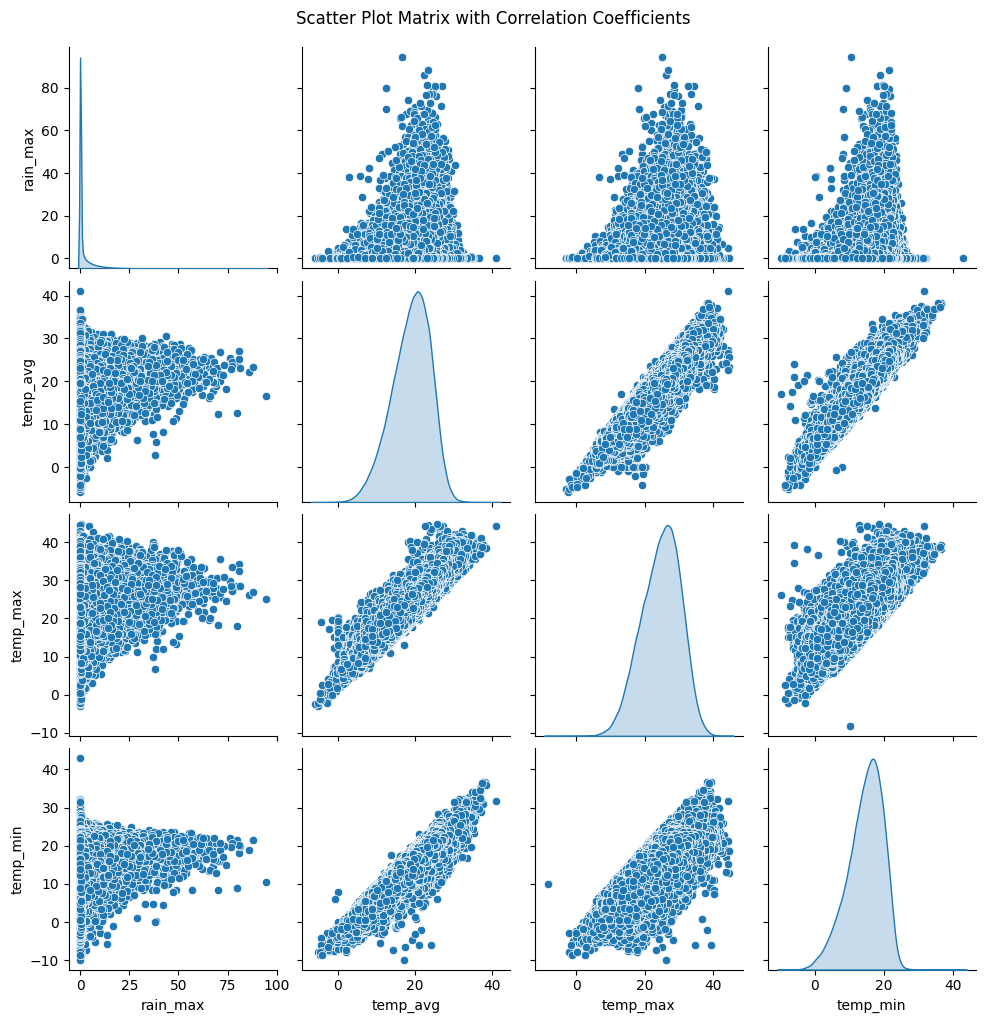

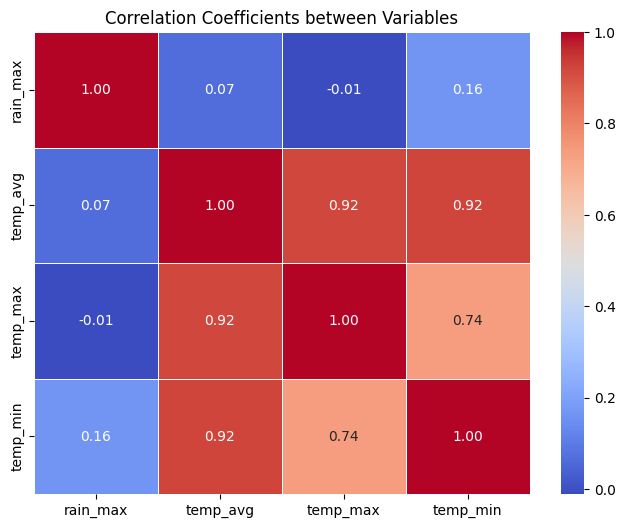

In [45]:
# Reset the index to ensure there are no duplicate labels
s_df_sum.reset_index(drop=True, inplace=True)

# Selecting relevant columns for analysis
selected_columns = ['rain_max', 'temp_avg', 'temp_max', 'temp_min']
df_selected = s_df_sum[selected_columns]

# Calculate the correlation matrix
correlation_matrix = df_selected.corr()

# Plotting the scatter plot matrix
sns.pairplot(df_selected, diag_kind='kde')
plt.suptitle('Scatter Plot Matrix with Correlation Coefficients', y=1.02)
plt.show()

# Plotting the correlation coefficients as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Coefficients between Variables')
plt.show()

In [46]:
# Selecting relevant columns for analysis
selected_columns = ['rain_max', 'temp_avg', 'temp_max', 'temp_min']
df_selected = n_df_sum[selected_columns]

# Calculating the correlation matrix
correlation_matrix = df_selected.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Specific correlations between rain_max and temperature variables
rain_temp_avg_corr = correlation_matrix.loc['rain_max', 'temp_avg']
rain_temp_max_corr = correlation_matrix.loc['rain_max', 'temp_max']
rain_temp_min_corr = correlation_matrix.loc['rain_max', 'temp_min']

print("\nCorrelation between rain_max and temp_avg:", rain_temp_avg_corr)
print("Correlation between rain_max and temp_max:", rain_temp_max_corr)
print("Correlation between rain_max and temp_min:", rain_temp_min_corr)

Correlation Matrix:
          rain_max  temp_avg  temp_max  temp_min
rain_max  1.000000 -0.254540 -0.295763  0.014538
temp_avg -0.254540  1.000000  0.674026  0.587868
temp_max -0.295763  0.674026  1.000000 -0.026146
temp_min  0.014538  0.587868 -0.026146  1.000000

Correlation between rain_max and temp_avg: -0.25453962067511066
Correlation between rain_max and temp_max: -0.2957631344241229
Correlation between rain_max and temp_min: 0.014537656819636173


/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning:

The figure layout has changed to tight



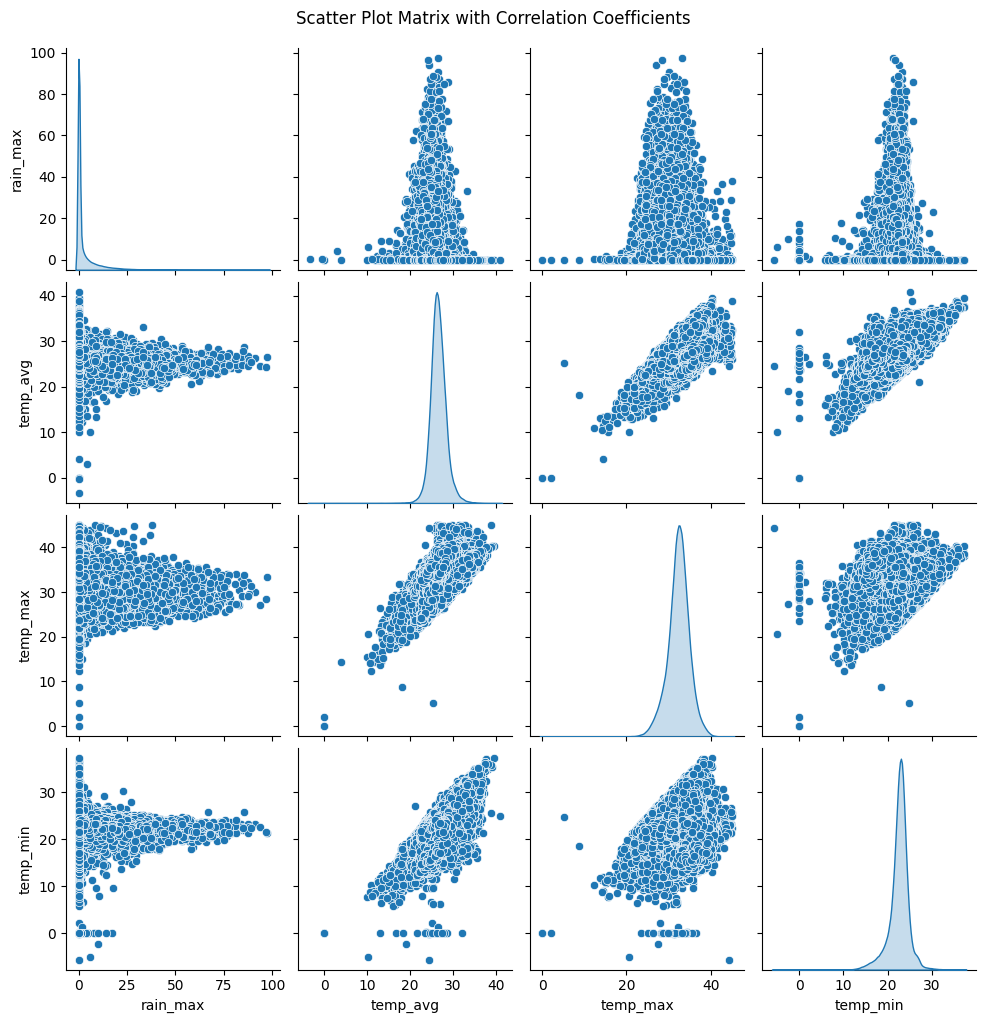

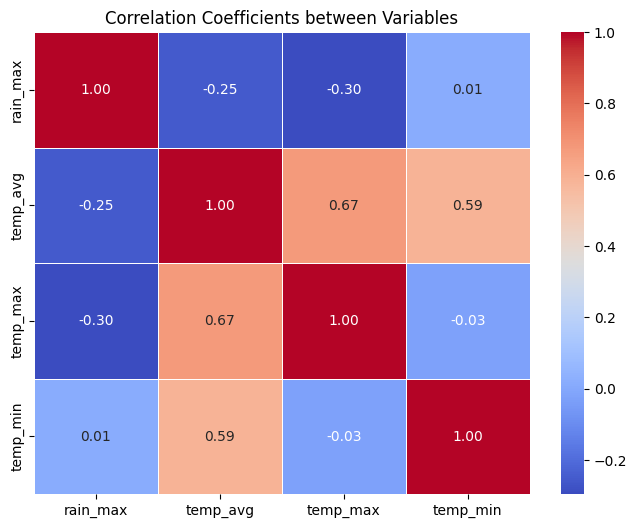

In [47]:
# Reset the index to ensure there are no duplicate labels
n_df_sum.reset_index(drop=True, inplace=True)

# Selecting relevant columns for analysis
selected_columns = ['rain_max', 'temp_avg', 'temp_max', 'temp_min']
df_selected = n_df_sum[selected_columns]

# Calculate the correlation matrix
correlation_matrix = df_selected.corr()

# Plotting the scatter plot matrix
sns.pairplot(df_selected, diag_kind='kde')
plt.suptitle('Scatter Plot Matrix with Correlation Coefficients', y=1.02)
plt.show()

# Plotting the correlation coefficients as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Coefficients between Variables')
plt.show()

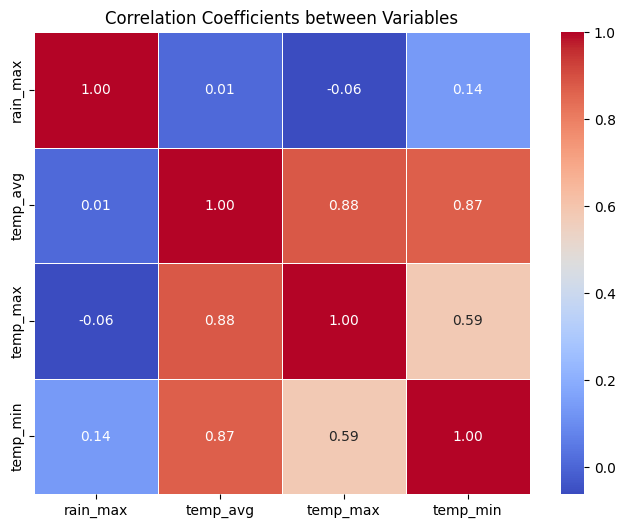

In [48]:
# Reset the index to ensure there are no duplicate labels
se_df_sum.reset_index(drop=True, inplace=True)

# Selecting relevant columns for analysis
selected_columns = ['rain_max', 'temp_avg', 'temp_max', 'temp_min']
df_selected = se_df_sum[selected_columns]

# Calculate the correlation matrix
correlation_matrix = df_selected.corr()

# Plotting the scatter plot matrix
# sns.pairplot(df_selected, diag_kind='kde')
# plt.suptitle('Scatter Plot Matrix with Correlation Coefficients', y=1.02)
# plt.show()

# Plotting the correlation coefficients as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Coefficients between Variables')
plt.show()

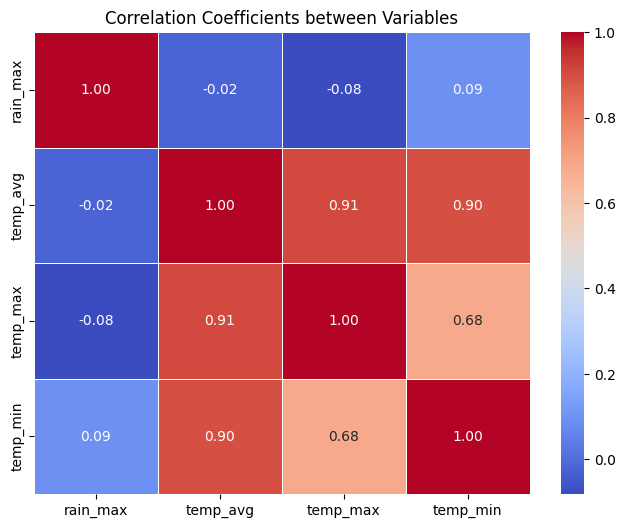

In [49]:
# Reset the index to ensure there are no duplicate labels
all_df_sum.reset_index(drop=True, inplace=True)

# Selecting relevant columns for analysis
selected_columns = ['rain_max', 'temp_avg', 'temp_max', 'temp_min']
df_selected = all_df_sum[selected_columns]

# Calculate the correlation matrix
correlation_matrix = df_selected.corr()

# Plotting the correlation coefficients as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Coefficients between Variables')
plt.show()

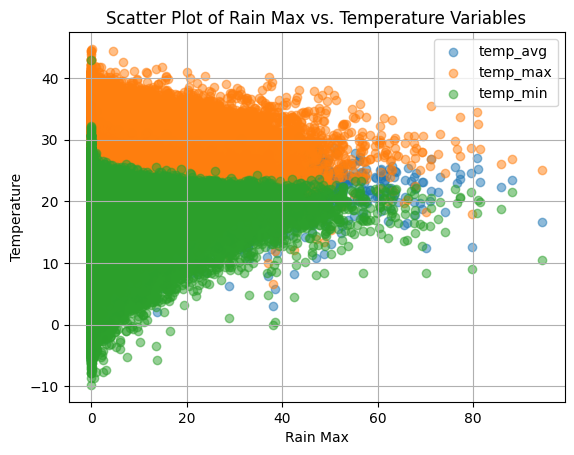

In [50]:
# Selecting relevant columns for analysis
selected_columns = ['rain_max', 'temp_avg', 'temp_max', 'temp_min']
df_selected = s_df_sum[selected_columns]

# Plotting scatter plots for each temperature variable against rain_max
for col in selected_columns[1:]:
    plt.scatter(df_selected['rain_max'], df_selected[col], alpha=0.5, label=col)

# Adding labels and title
plt.xlabel('Rain Max')
plt.ylabel('Temperature')
plt.title('Scatter Plot of Rain Max vs. Temperature Variables')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

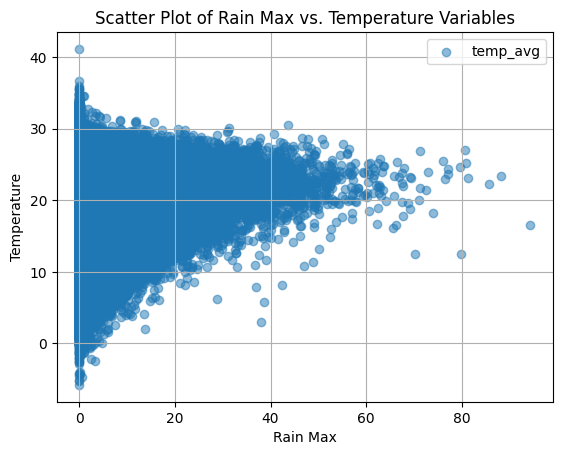

In [51]:
# selected_columns = ['rain_max', 'temp_avg', 'temp_max', 'temp_min']
selected_columns = ['rain_max', 'temp_avg']
df_selected = s_df_sum[selected_columns]

# Plotting scatter plots for each temperature variable against rain_max
for col in selected_columns[1:]:
    plt.scatter(df_selected['rain_max'], df_selected[col], alpha=0.5, label=col)

# Adding labels and title
plt.xlabel('Rain Max')
plt.ylabel('Temperature')
plt.title('Scatter Plot of Rain Max vs. Temperature Variables')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

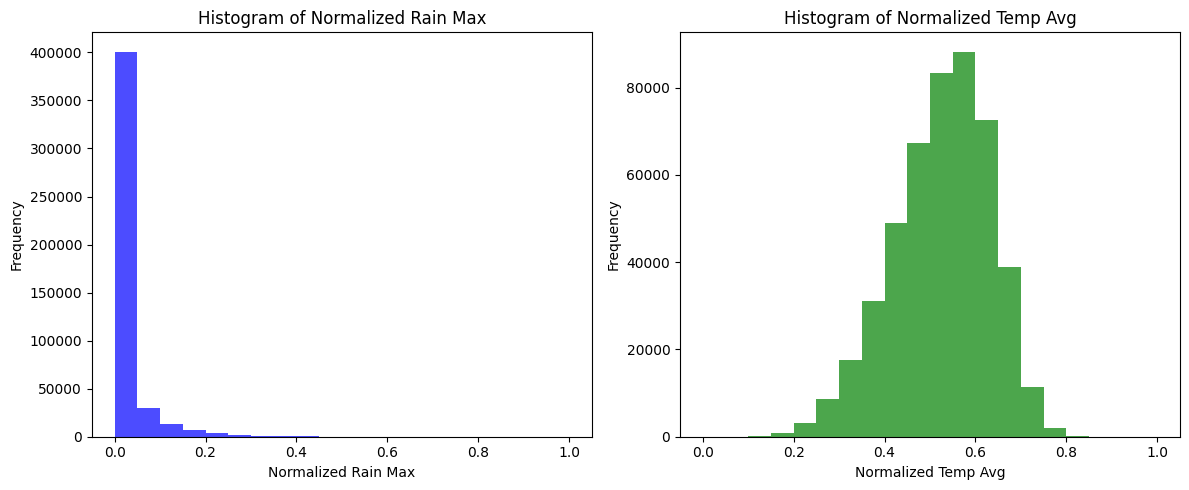

In [52]:
from sklearn.preprocessing import MinMaxScaler

# Assuming 's_df_sum' is your DataFrame

# Select relevant columns for analysis
selected_columns = ['rain_max', 'temp_avg']
df_selected = s_df_sum[selected_columns]

# Normalize the selected columns
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df_selected)
df_normalized = pd.DataFrame(normalized_data, columns=selected_columns)

# Plot normalized histograms
plt.figure(figsize=(12, 5))

# Plot histogram for rain_max
plt.subplot(1, 2, 1)
plt.hist(df_normalized['rain_max'], bins=20, color='blue', alpha=0.7)
plt.xlabel('Normalized Rain Max')
plt.ylabel('Frequency')
plt.title('Histogram of Normalized Rain Max')

# Plot histogram for temp_avg
plt.subplot(1, 2, 2)
plt.hist(df_normalized['temp_avg'], bins=20, color='green', alpha=0.7)
plt.xlabel('Normalized Temp Avg')
plt.ylabel('Frequency')
plt.title('Histogram of Normalized Temp Avg')

plt.tight_layout()
plt.show()

/tmp/ipykernel_20/1345491308.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



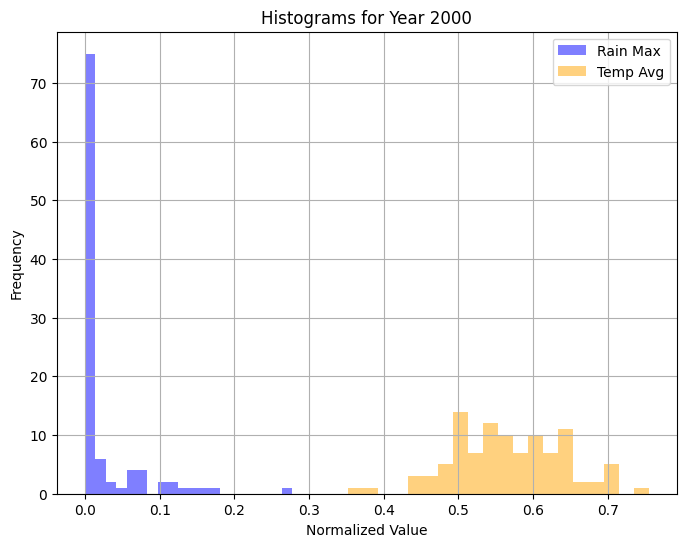

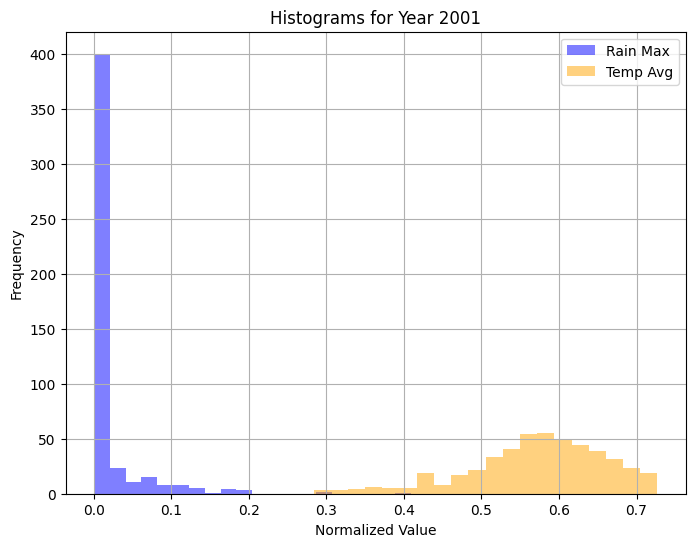

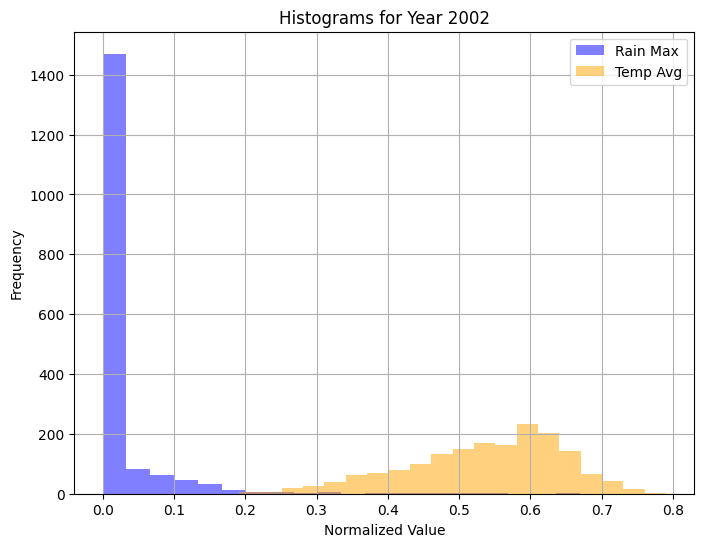

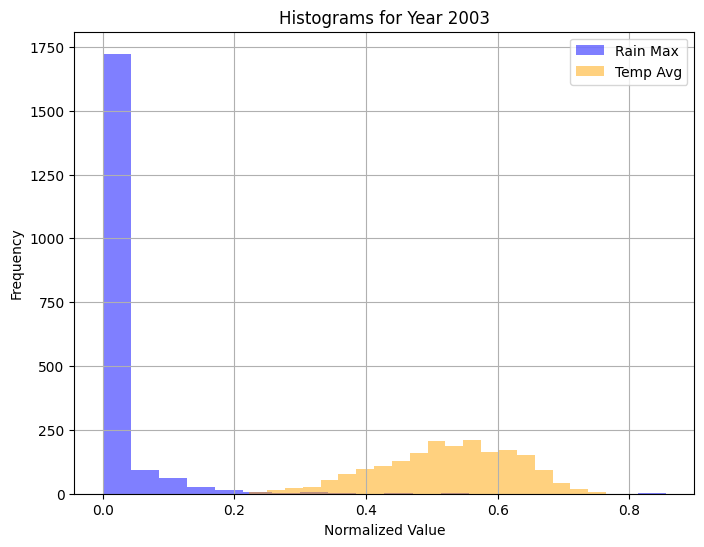

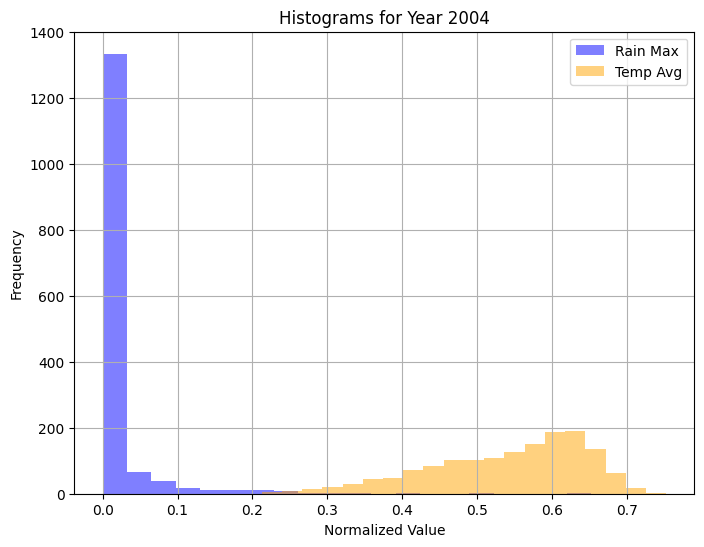

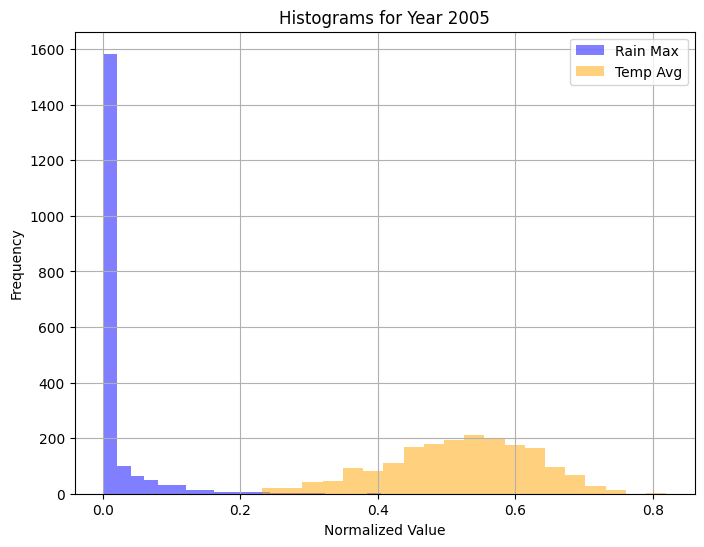

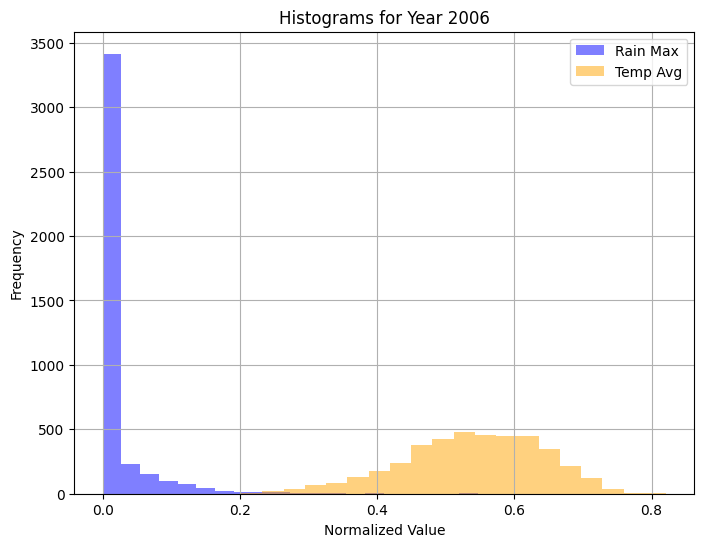

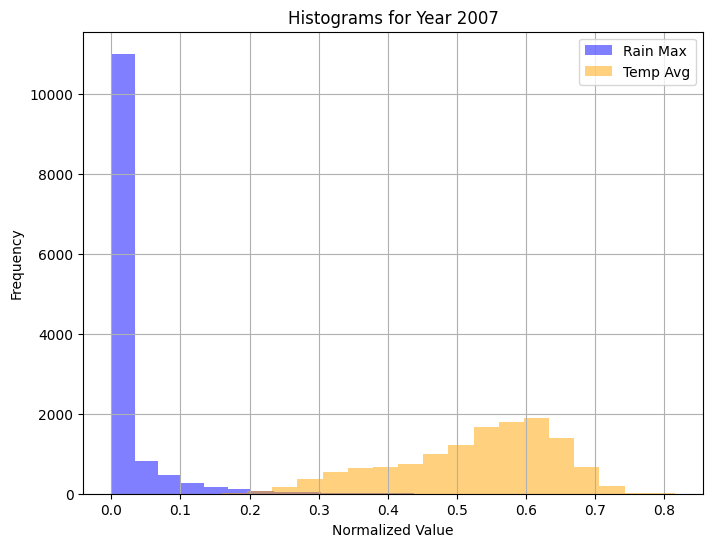

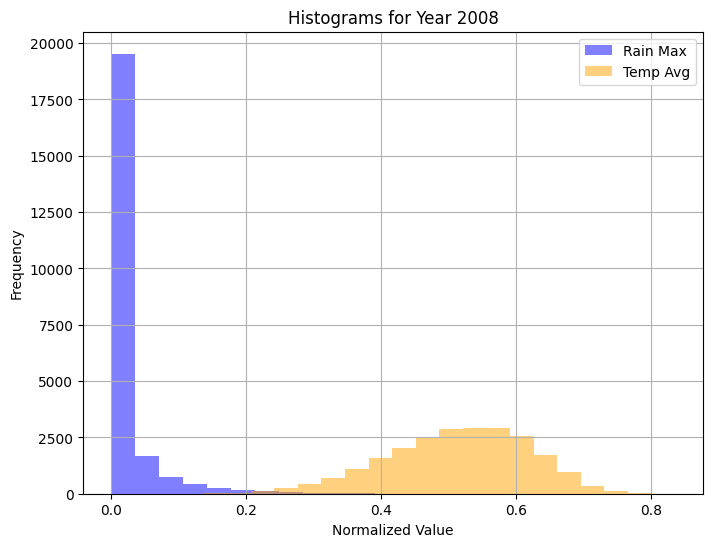

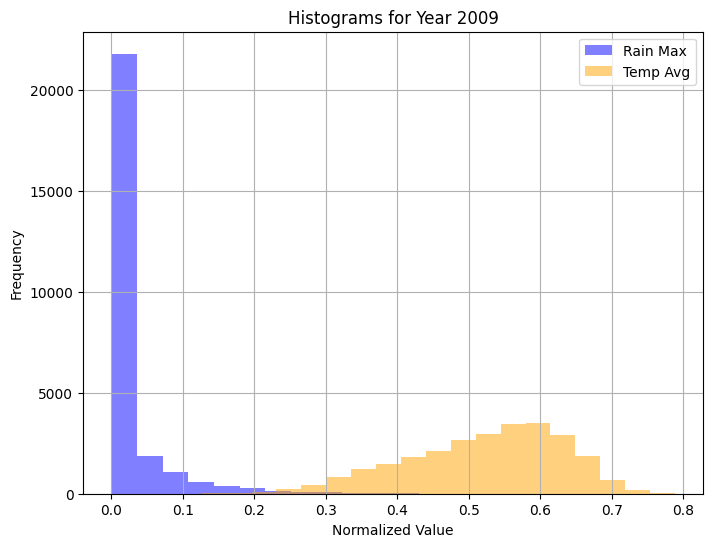

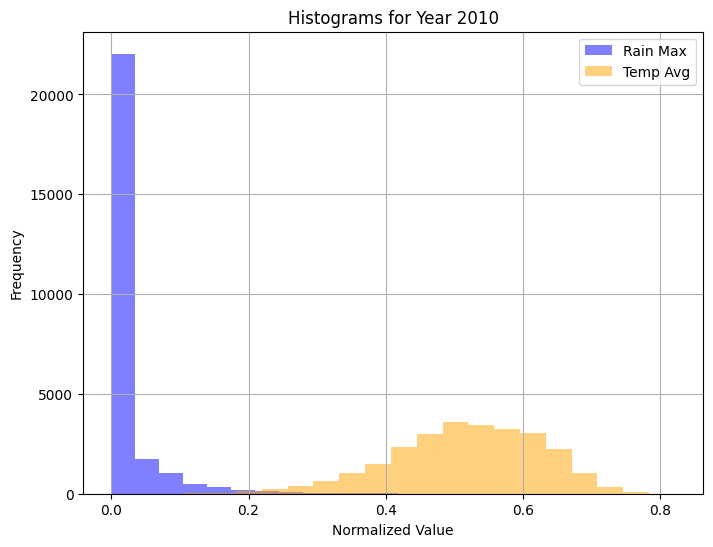

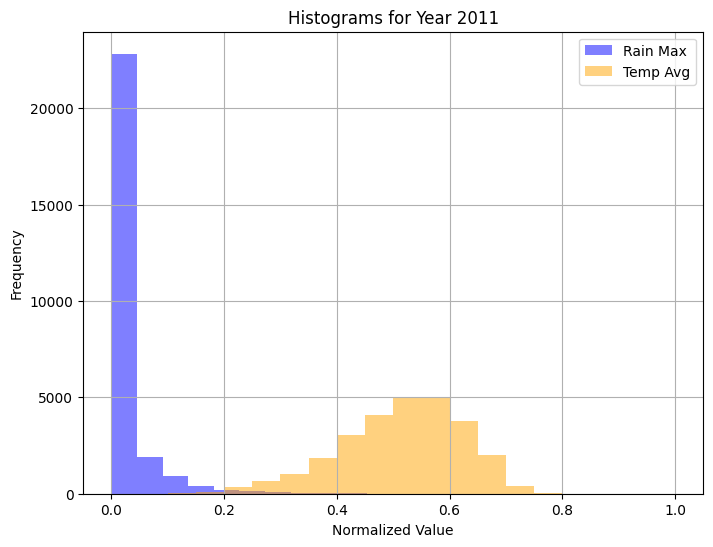

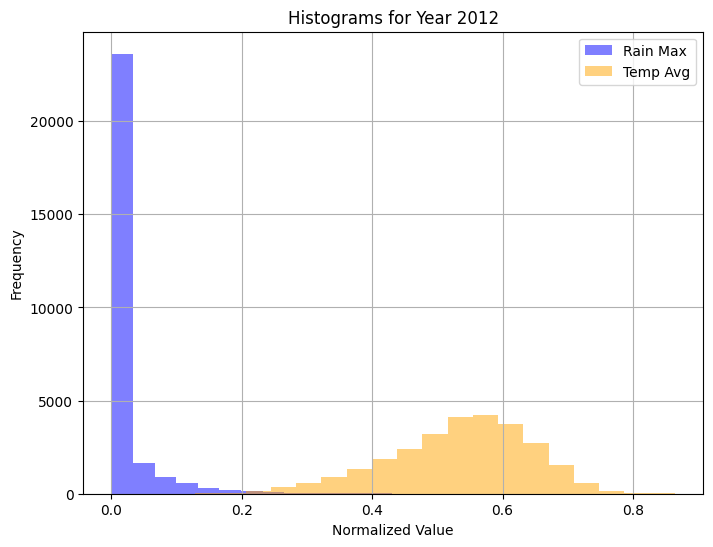

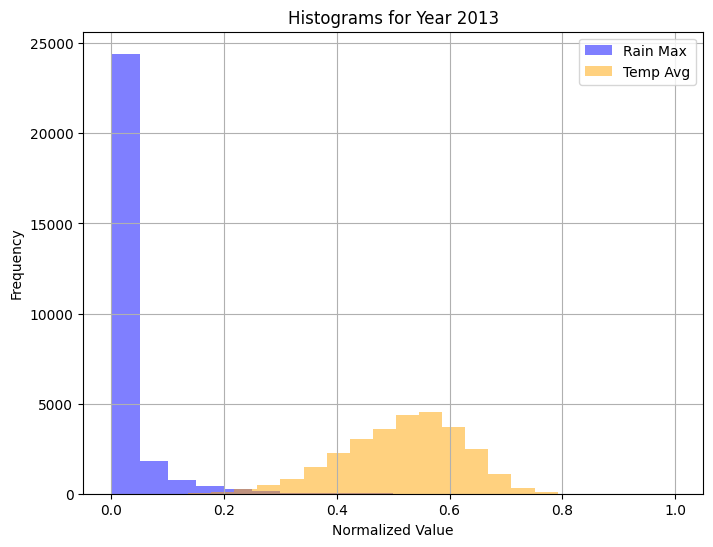

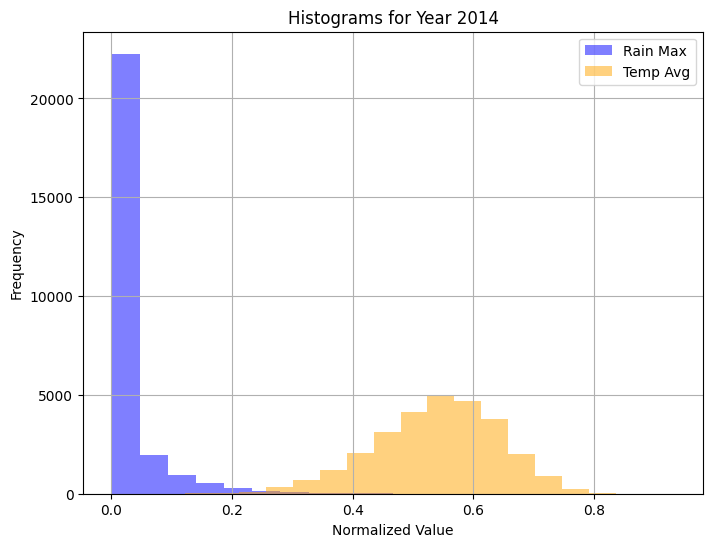

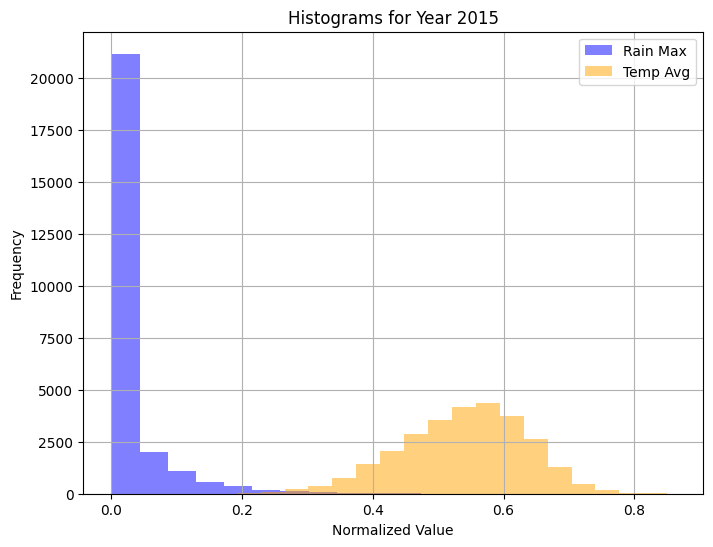

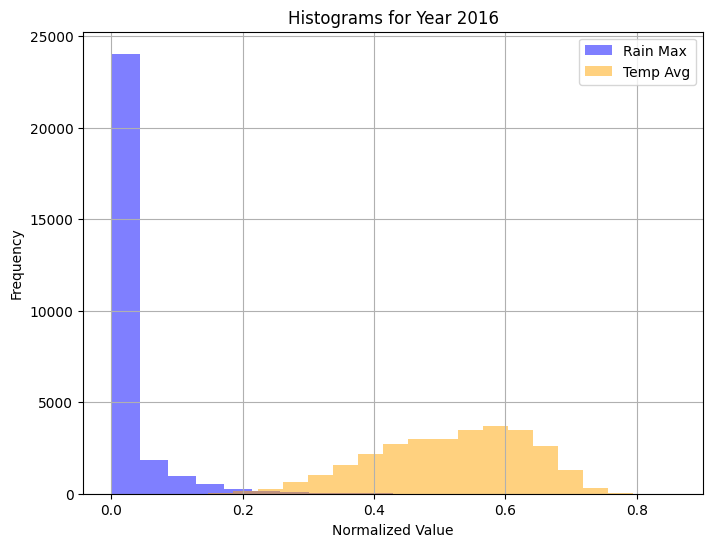

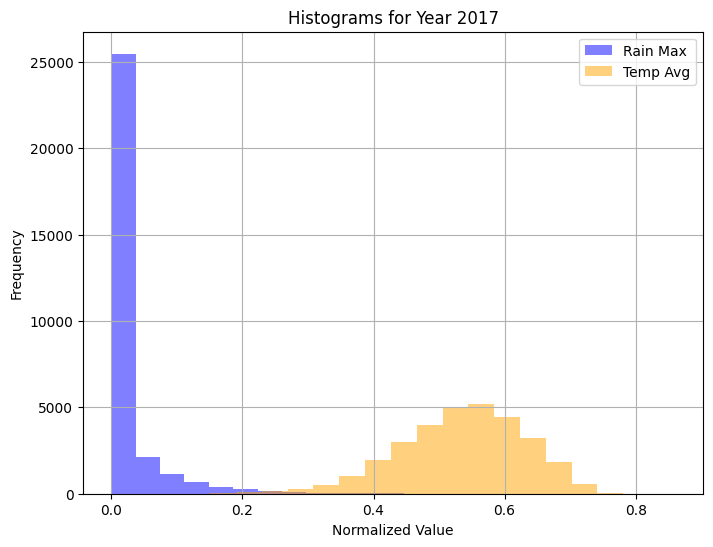

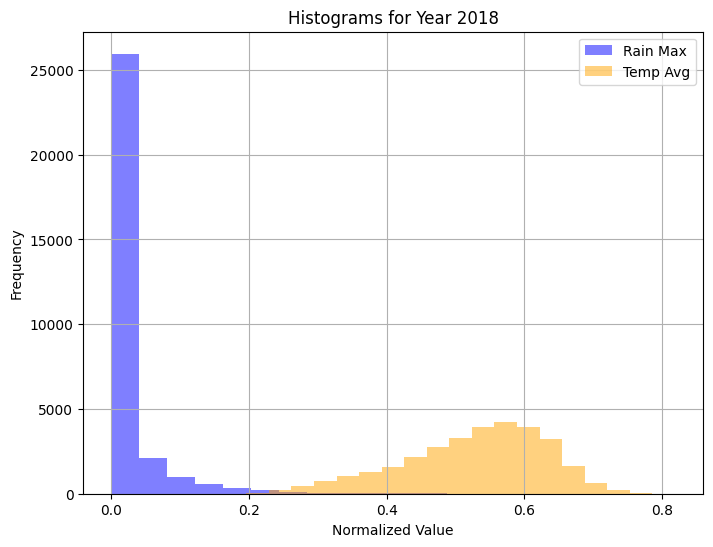

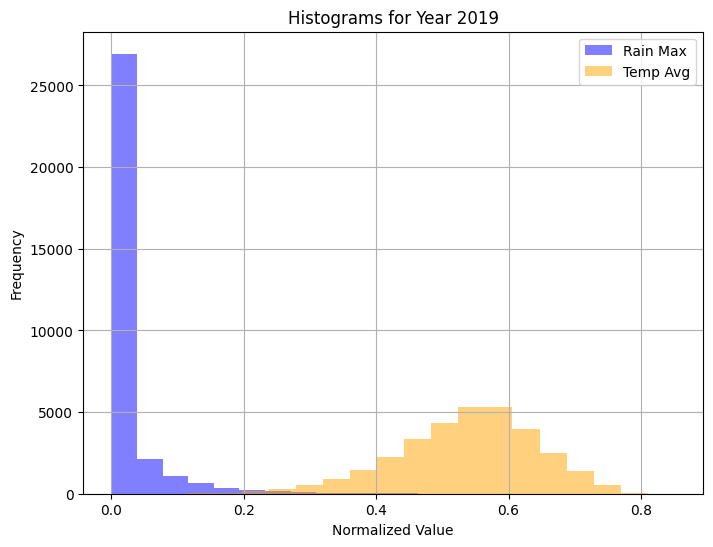

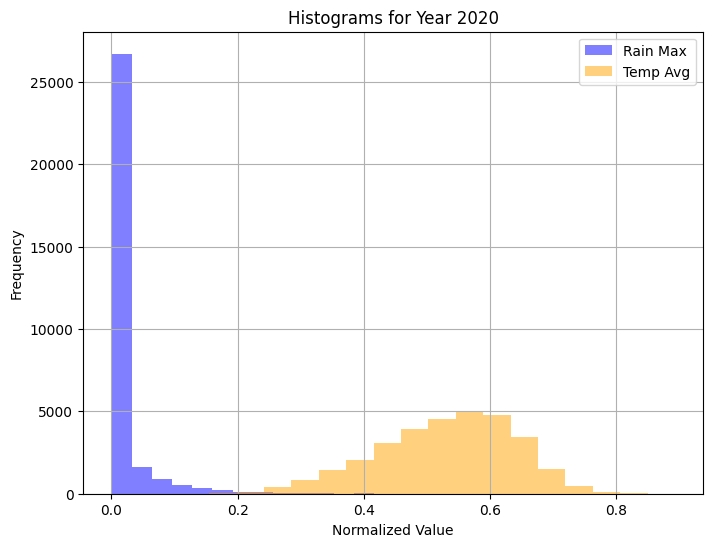

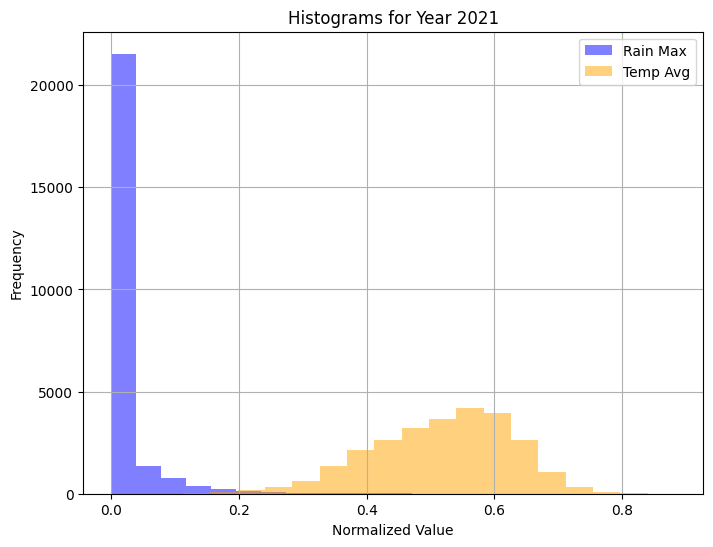

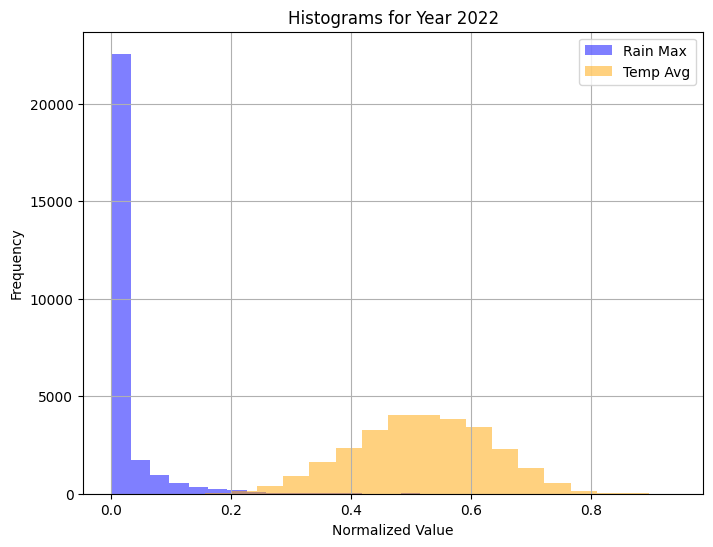

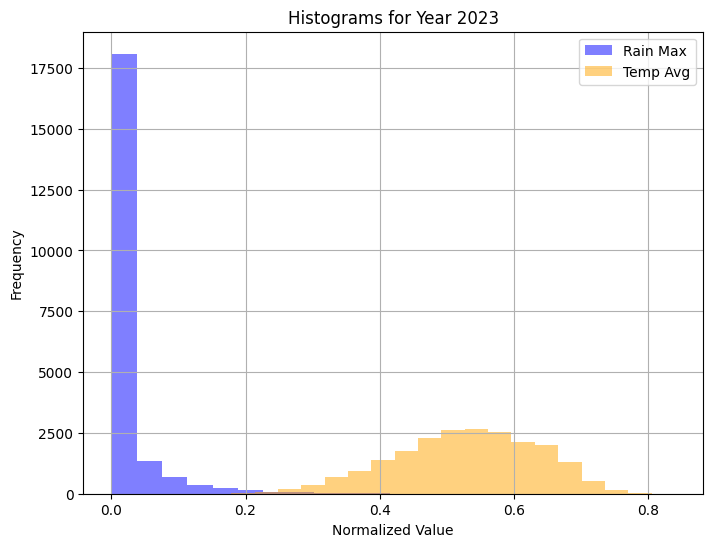

In [53]:
# Extract the year from the 'DATA' column
s_df_sum['YEAR'] = pd.to_datetime(s_df_sum['DATA (YYYY-MM-DD)']).dt.year

# Select relevant columns and normalize them
selected_columns = ['YEAR', 'rain_max', 'temp_avg']
df_selected = s_df_sum[selected_columns]

# Initialize the Min-Max scaler
scaler = MinMaxScaler()

# Normalize 'rain_max' and 'temp_avg'
df_selected[['rain_max', 'temp_avg']] = scaler.fit_transform(df_selected[['rain_max', 'temp_avg']])

# Create histograms by year
for year in df_selected['YEAR'].unique():
    subset = df_selected[df_selected['YEAR'] == year]
    
    plt.figure(figsize=(8, 6))
    plt.hist(subset['rain_max'], bins=20, alpha=0.5, label='Rain Max', color='blue')
    plt.hist(subset['temp_avg'], bins=20, alpha=0.5, label='Temp Avg', color='orange')
    
    plt.xlabel('Normalized Value')
    plt.ylabel('Frequency')
    plt.title(f'Histograms for Year {year}')
    plt.legend()
    plt.grid(True)
    
    plt.show()

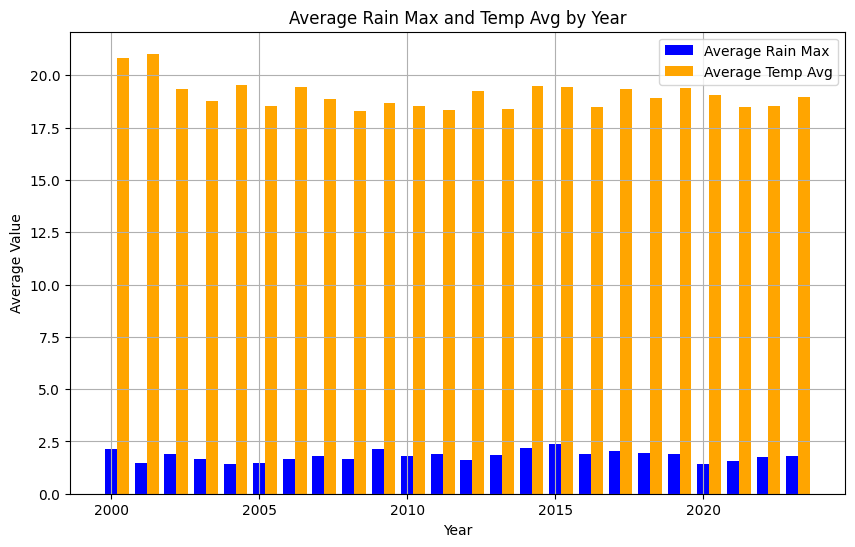

In [54]:
# Extract the year from the 'DATA' column
s_df_sum['YEAR'] = pd.to_datetime(s_df_sum['DATA (YYYY-MM-DD)']).dt.year

# Calculate average 'rain_max' and 'temp_avg' for each year
average_by_year = s_df_sum.groupby('YEAR')[['rain_max', 'temp_avg']].mean().reset_index()

# Plotting the average values for each year
plt.figure(figsize=(10, 6))
plt.bar(average_by_year['YEAR'], average_by_year['rain_max'], width=0.4, label='Average Rain Max', color='blue')
plt.bar(average_by_year['YEAR'] + 0.4, average_by_year['temp_avg'], width=0.4, label='Average Temp Avg', color='orange')

plt.xlabel('Year')
plt.ylabel('Average Value')
plt.title('Average Rain Max and Temp Avg by Year')
plt.legend()
plt.grid(True)
plt.show()

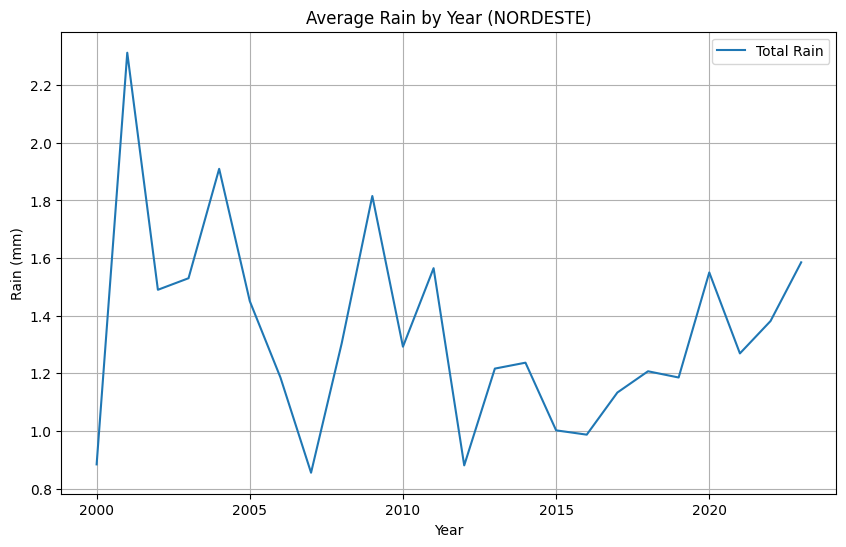

In [55]:
ne_df_sum = ne_df_sum.copy()
ne_df_sum['DATA (YYYY-MM-DD)'] = pd.to_datetime(ne_df_sum['DATA (YYYY-MM-DD)'])

# Extract the year from the date
ne_df_sum['Year'] = ne_df_sum['DATA (YYYY-MM-DD)'].dt.year

# Group by year and calculate the average rain for each year
ne_average_rain_by_year = ne_df_sum.groupby('Year')['rain_max'].mean()

# Plot the average rain by year
plt.figure(figsize=(10, 6))
plt.plot(ne_average_rain_by_year.index, ne_average_rain_by_year, label='Total Rain')

plt.xlabel('Year')
plt.ylabel('Rain (mm)')
plt.title('Average Rain by Year (NORDESTE)')
plt.legend()
plt.grid(True)
plt.show()

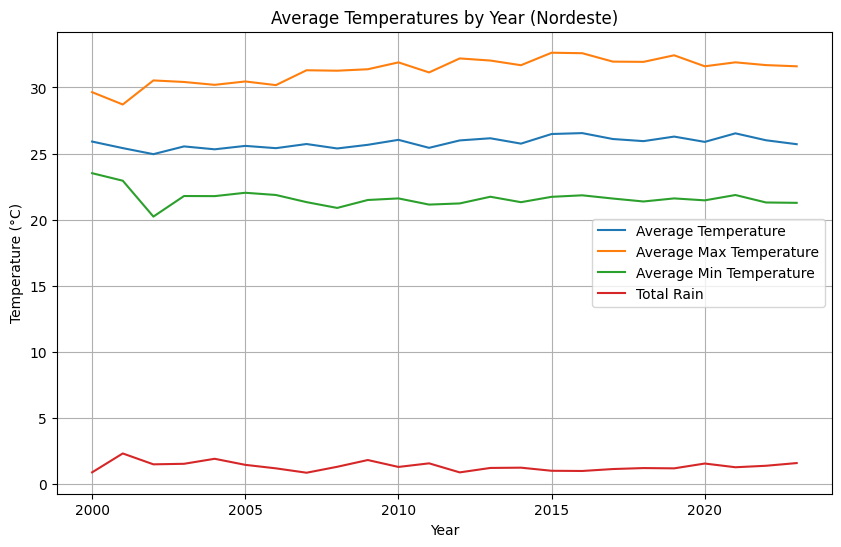

In [56]:
# Plot the average temperatures by year
plt.figure(figsize=(10, 6))
plt.plot(ne_average_temperature_by_year.index, ne_average_temperature_by_year, label='Average Temperature')
plt.plot(ne_avarage_max_temperature_by_year.index, ne_avarage_max_temperature_by_year, label='Average Max Temperature')
plt.plot(ne_avarage_min_temperature_by_year.index, ne_avarage_min_temperature_by_year, label='Average Min Temperature')
plt.plot(ne_average_rain_by_year.index, ne_average_rain_by_year, label='Total Rain')



plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.title('Average Temperatures by Year (Nordeste)')
plt.legend()
plt.grid(True)
plt.show()

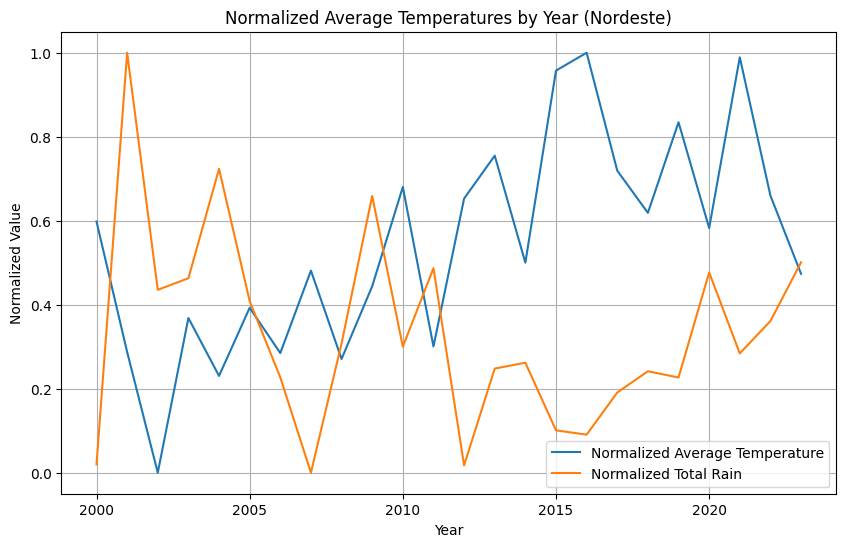

In [57]:
# Create a MinMaxScaler
scaler = MinMaxScaler()

# Normalize the data
ne_average_temperature_by_year_normalized = scaler.fit_transform(ne_average_temperature_by_year.values.reshape(-1, 1))
# ne_avarage_max_temperature_by_year_normalized = scaler.fit_transform(ne_avarage_max_temperature_by_year.values.reshape(-1, 1))
# ne_avarage_min_temperature_by_year_normalized = scaler.fit_transform(ne_avarage_min_temperature_by_year.values.reshape(-1, 1))
ne_average_rain_by_year_normalized = scaler.fit_transform(ne_average_rain_by_year.values.reshape(-1, 1))

# Plot the normalized data
plt.figure(figsize=(10, 6))
plt.plot(ne_average_temperature_by_year.index, ne_average_temperature_by_year_normalized, label='Normalized Average Temperature')
# plt.plot(ne_avarage_max_temperature_by_year.index, ne_avarage_max_temperature_by_year_normalized, label='Normalized Average Max Temperature')
# plt.plot(ne_avarage_min_temperature_by_year.index, ne_avarage_min_temperature_by_year_normalized, label='Normalized Average Min Temperature')
plt.plot(ne_average_rain_by_year.index, ne_average_rain_by_year_normalized, label='Normalized Total Rain')

plt.xlabel('Year')
plt.ylabel('Normalized Value')
plt.title('Normalized Average Temperatures by Year (Nordeste)')
plt.legend()
plt.grid(True)
plt.show()

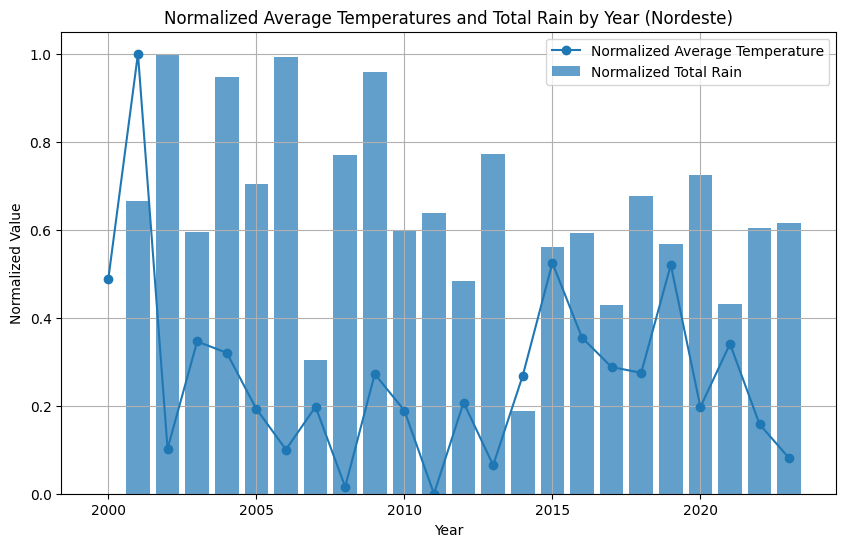

In [58]:
# Create a MinMaxScaler
scaler = MinMaxScaler()

# Normalize the data
se_average_temperature_by_year_normalized = scaler.fit_transform(se_average_temperature_by_year.values.reshape(-1, 1))
se_average_rain_by_year_normalized = scaler.fit_transform(se_average_rain_by_year.values.reshape(-1, 1))

# Plot the normalized data
plt.figure(figsize=(10, 6))

# Plot normalized average temperature as lines
plt.plot(se_average_temperature_by_year.index, se_average_temperature_by_year_normalized, label='Normalized Average Temperature', marker='o')

# Plot normalized total rain as bars
plt.bar(se_average_rain_by_year.index, se_average_rain_by_year_normalized.flatten(), label='Normalized Total Rain', alpha=0.7)

plt.xlabel('Year')
plt.ylabel('Normalized Value')
plt.title('Normalized Average Temperatures and Total Rain by Year (Nordeste)')
plt.legend()
plt.grid(True)
plt.show()

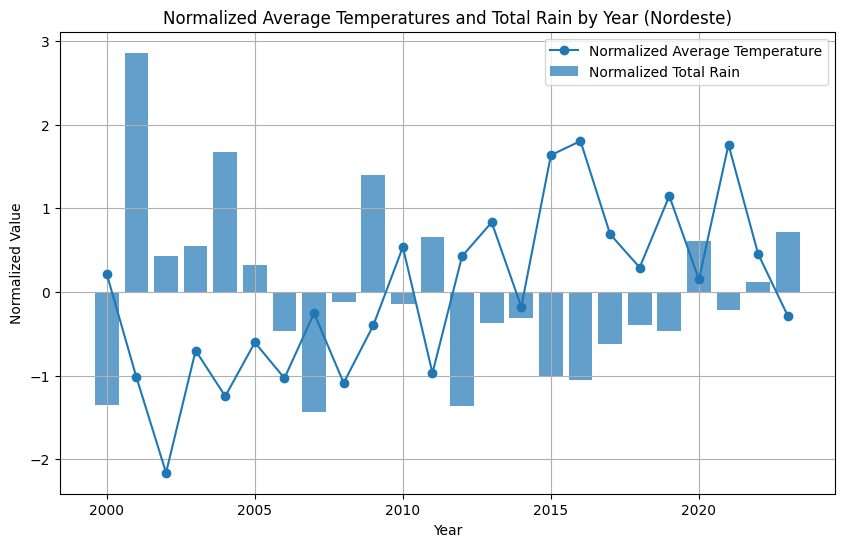

In [59]:
# Create a StandardScaler (Z-score normalization)
scaler = StandardScaler()

# Normalize the data using Z-score normalization
ne_average_temperature_by_year_normalized = scaler.fit_transform(ne_average_temperature_by_year.values.reshape(-1, 1))
ne_average_rain_by_year_normalized = scaler.fit_transform(ne_average_rain_by_year.values.reshape(-1, 1))

# Plot the normalized data
plt.figure(figsize=(10, 6))

# Plot normalized average temperature as lines
plt.plot(ne_average_temperature_by_year.index, ne_average_temperature_by_year_normalized, label='Normalized Average Temperature', marker='o')

# Plot normalized total rain as bars
plt.bar(ne_average_rain_by_year.index, ne_average_rain_by_year_normalized.flatten(), label='Normalized Total Rain', alpha=0.7)

plt.xlabel('Year')
plt.ylabel('Normalized Value')
plt.title('Normalized Average Temperatures and Total Rain by Year (Nordeste)')
plt.legend()
plt.grid(True)
plt.show()

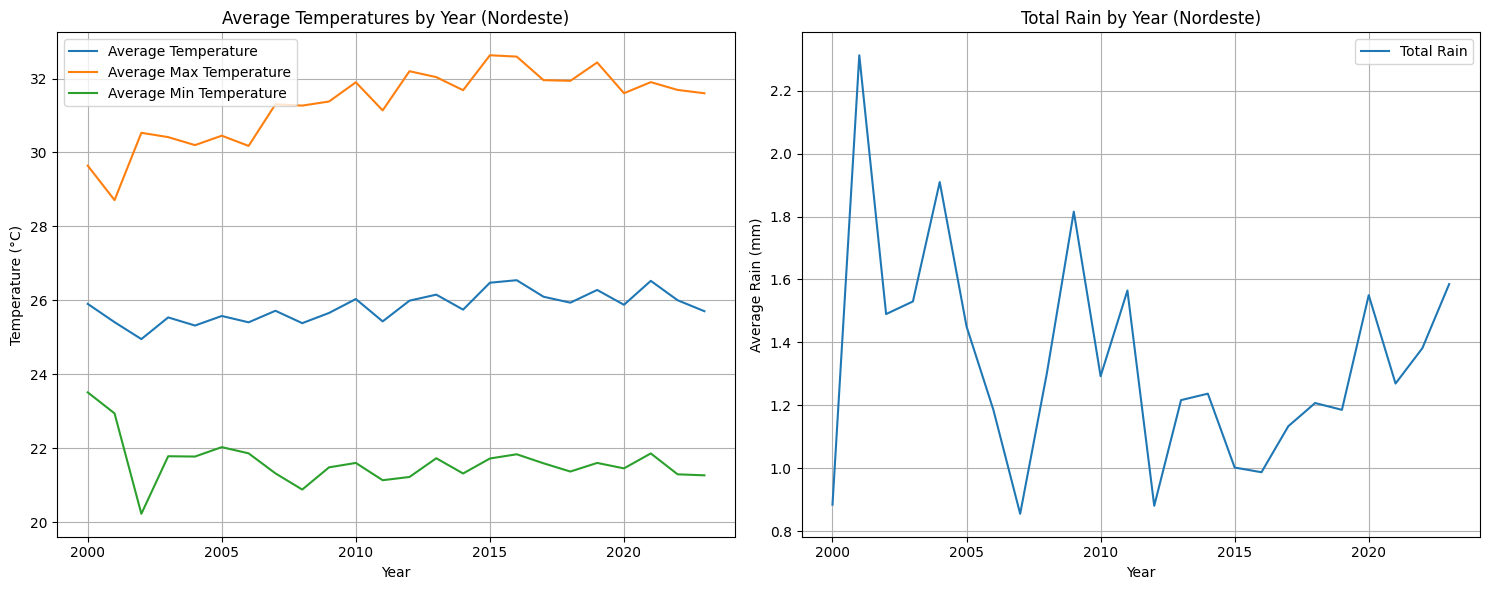

In [60]:
# Create subplots with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Plot average temperatures on the left plot
axs[0].plot(ne_average_temperature_by_year.index, ne_average_temperature_by_year, label='Average Temperature')
axs[0].plot(ne_avarage_max_temperature_by_year.index, ne_avarage_max_temperature_by_year, label='Average Max Temperature')
axs[0].plot(ne_avarage_min_temperature_by_year.index, ne_avarage_min_temperature_by_year, label='Average Min Temperature')
axs[0].set_xlabel('Year')
axs[0].set_ylabel('Temperature (°C)')
axs[0].set_title('Average Temperatures by Year (Nordeste)')
axs[0].legend()
axs[0].grid(True)

# Plot total rain on the right plot
axs[1].plot(ne_average_rain_by_year.index, ne_average_rain_by_year, label='Total Rain')
axs[1].set_xlabel('Year')
axs[1].set_ylabel('Average Rain (mm)')
axs[1].set_title('Total Rain by Year (Nordeste)')
axs[1].legend()
axs[1].grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [61]:
df_2010_sum

,ESTACAO,DATA (YYYY-MM-DD),rain_max,rad_max,temp_avg,temp_max,temp_min,hum_max,hum_min,wind_max,wind_avg
0,A001,2010-01-01,5.4,2640.4,22.035714,26.0,18.9,96.0,61.0,7.9,2.592857
1,A001,2010-01-02,3.0,3251.9,21.333333,26.5,18.2,95.0,52.0,11.4,3.737500
2,A001,2010-01-03,0.2,3952.4,22.829167,28.1,18.0,95.0,47.0,9.3,2.887500
3,A001,2010-01-04,0.0,3763.9,23.900000,29.2,19.7,75.0,41.0,9.0,3.066667
4,A001,2010-01-05,0.0,3600.3,24.391667,29.5,17.6,85.0,33.0,8.1,1.895833
...,...,...,...,...,...,...,...,...,...,...,...
150941,A868,2010-12-27,0.0,4105.4,23.058333,28.8,18.1,95.0,44.0,8.9,2.112500
150942,A868,2010-12-28,0.0,4261.8,23.150000,28.2,18.4,96.0,49.0,8.9,1.962500
150943,A868,2010-12-29,0.2,2598.4,22.345833,27.1,18.3,94.0,63.0,9.5,1.933333
150944,A868,2010-12-30,0.0,4071.3,23.533333,29.6,18.2,93.0,46.0,10.0,2.362500
